=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===

Fitting Baseline Models with Robust Error Catching...

Extracting CLOUD (MCMC) Parameters across restricted domains...
 -> Processing 4. CLOUD...

Aggregating Results...
Generating Final Publication Visuals in PNG, SVG, and PDF formats...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. Naive LMM  2. LPMM Approximation  3. Univariate CAR(1)  4. CLOUD
Target                                                                          
Total Score         2.552                  2.465                 4.106     1.410
Bulbar              0.841                  2.313                 1.013     0.685
Fine_Motor          0.982                  2.035                 1.259     0.502
Gross_Motor         0.971                  2.172                 1.297     0.974
Respiratory         0.988                  1.478                 1.220     0.490

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)
M

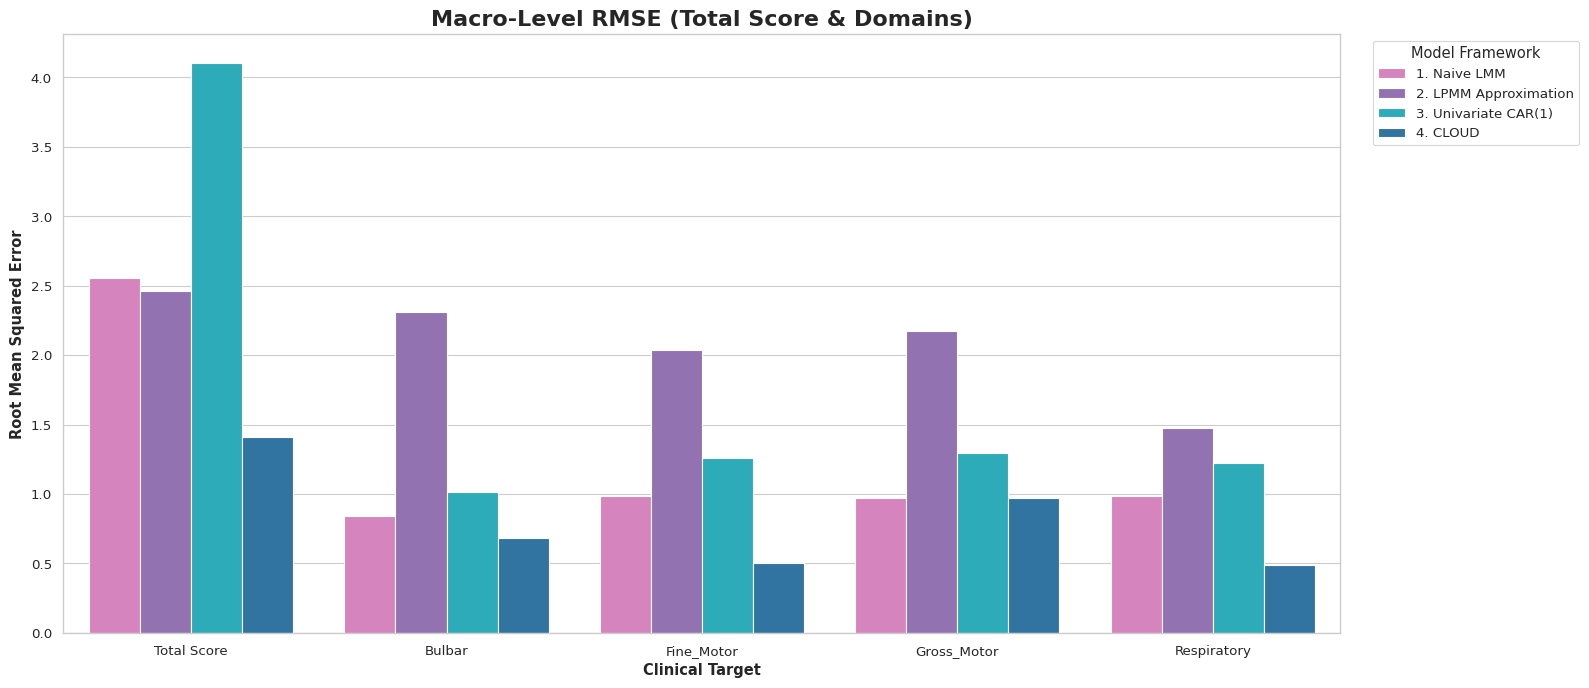

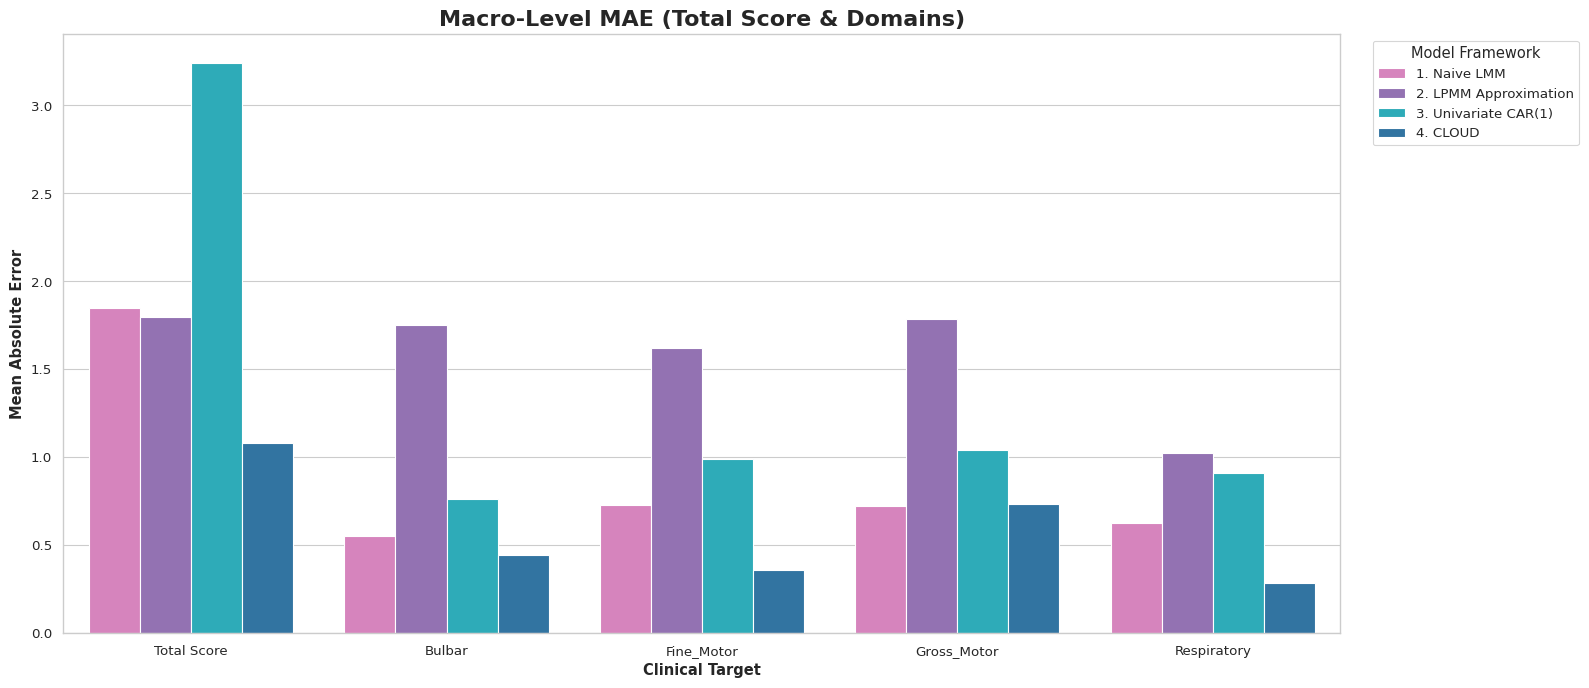

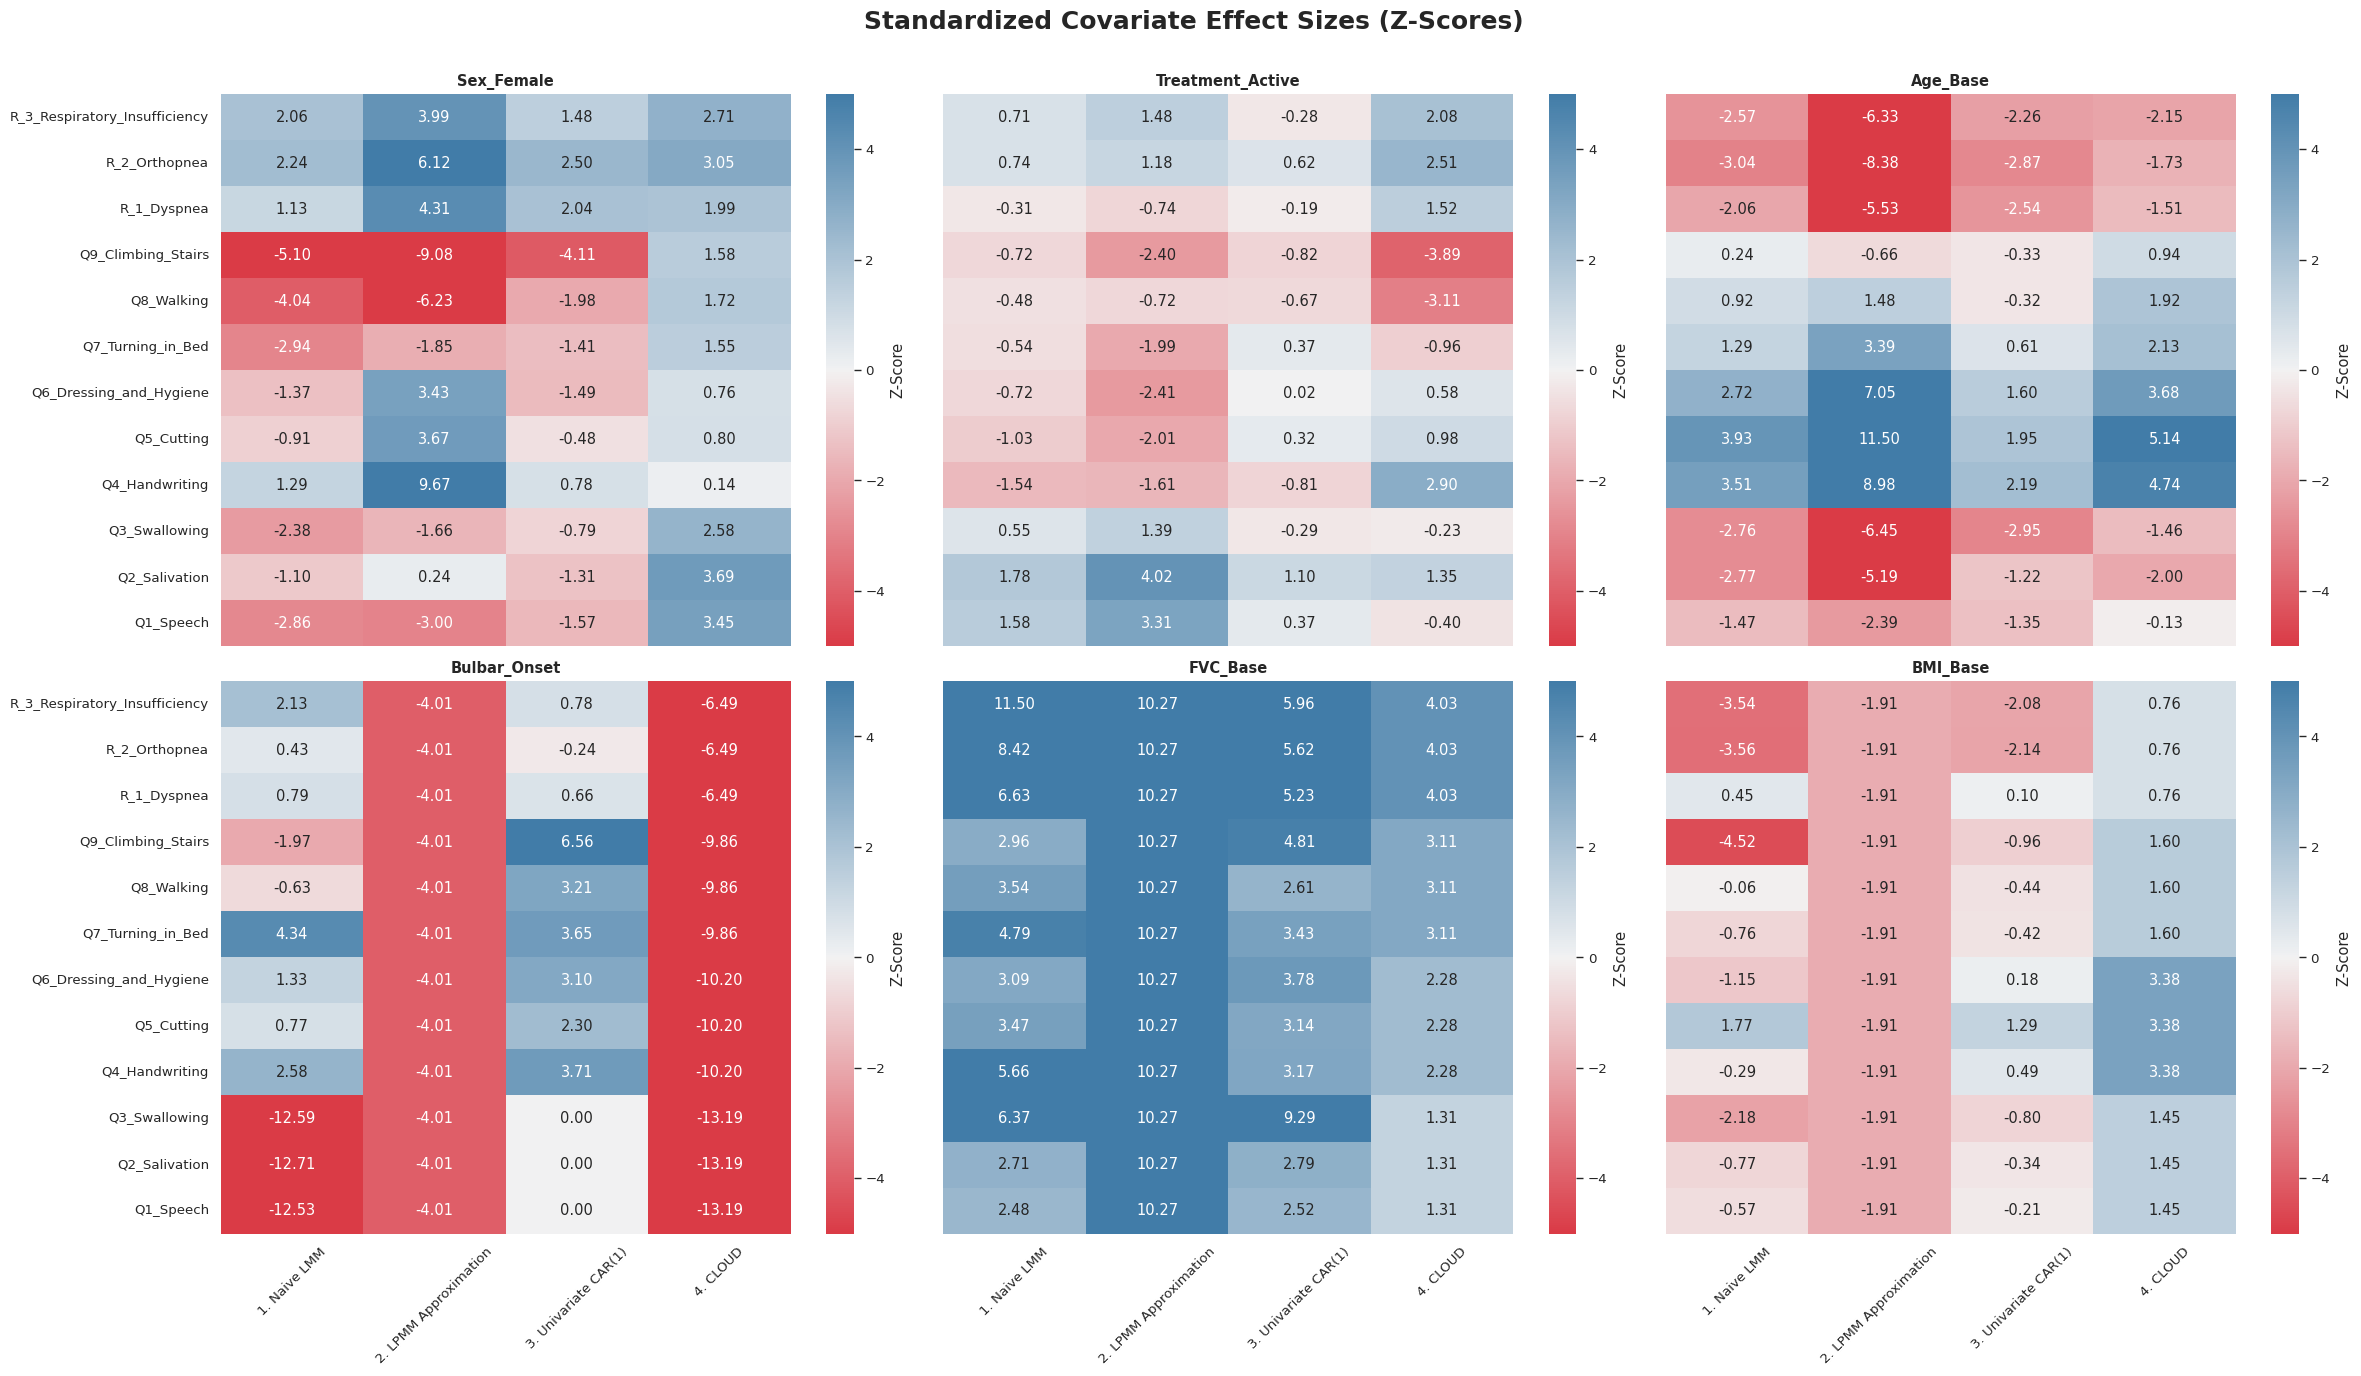

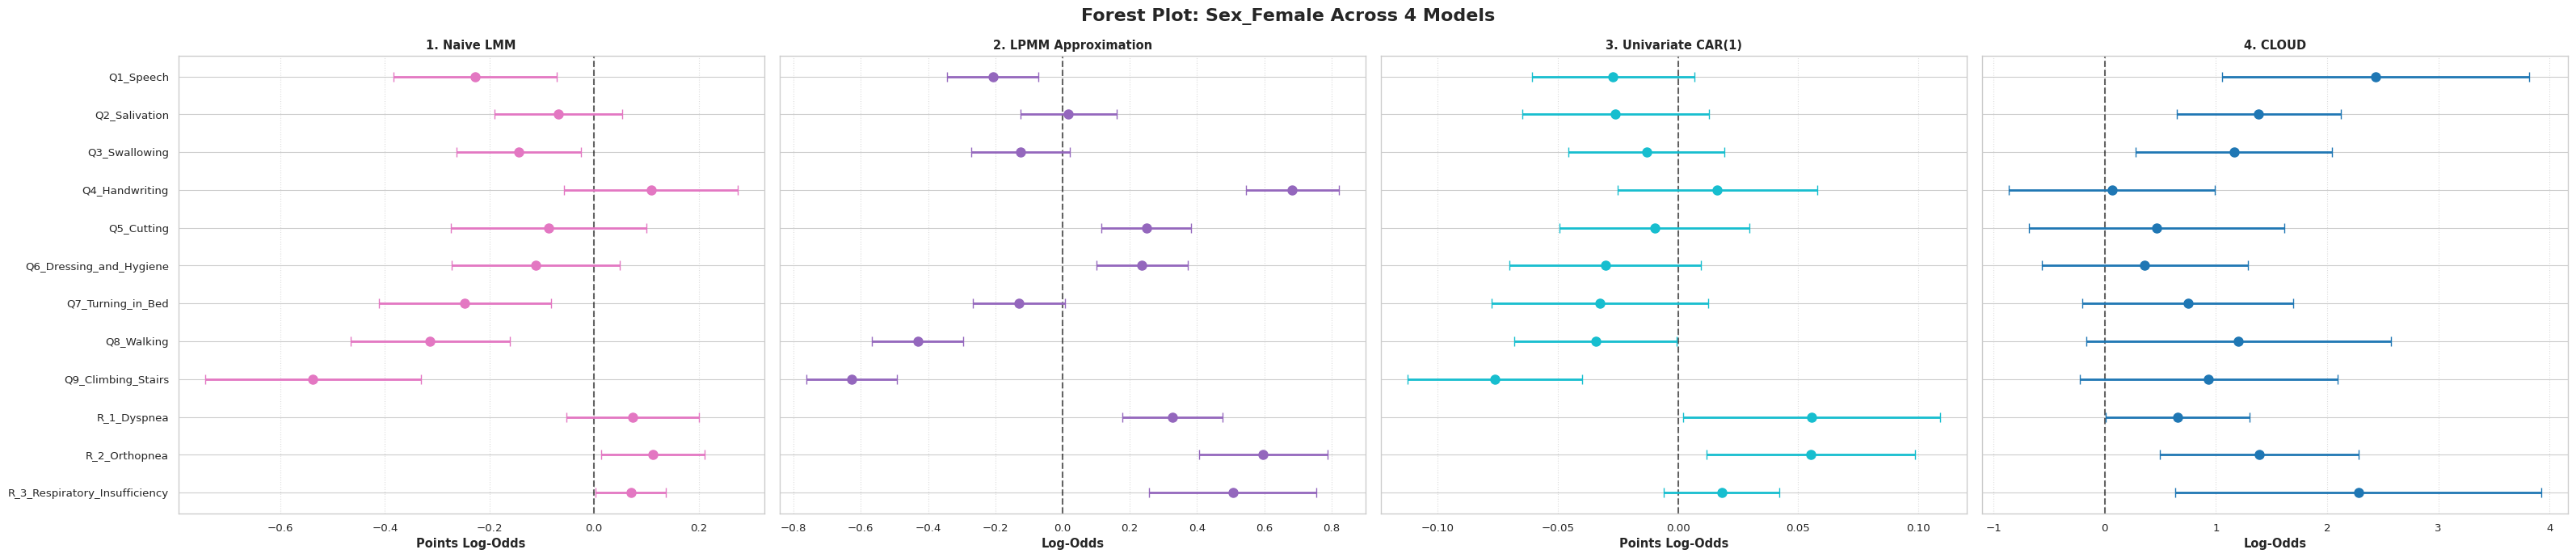

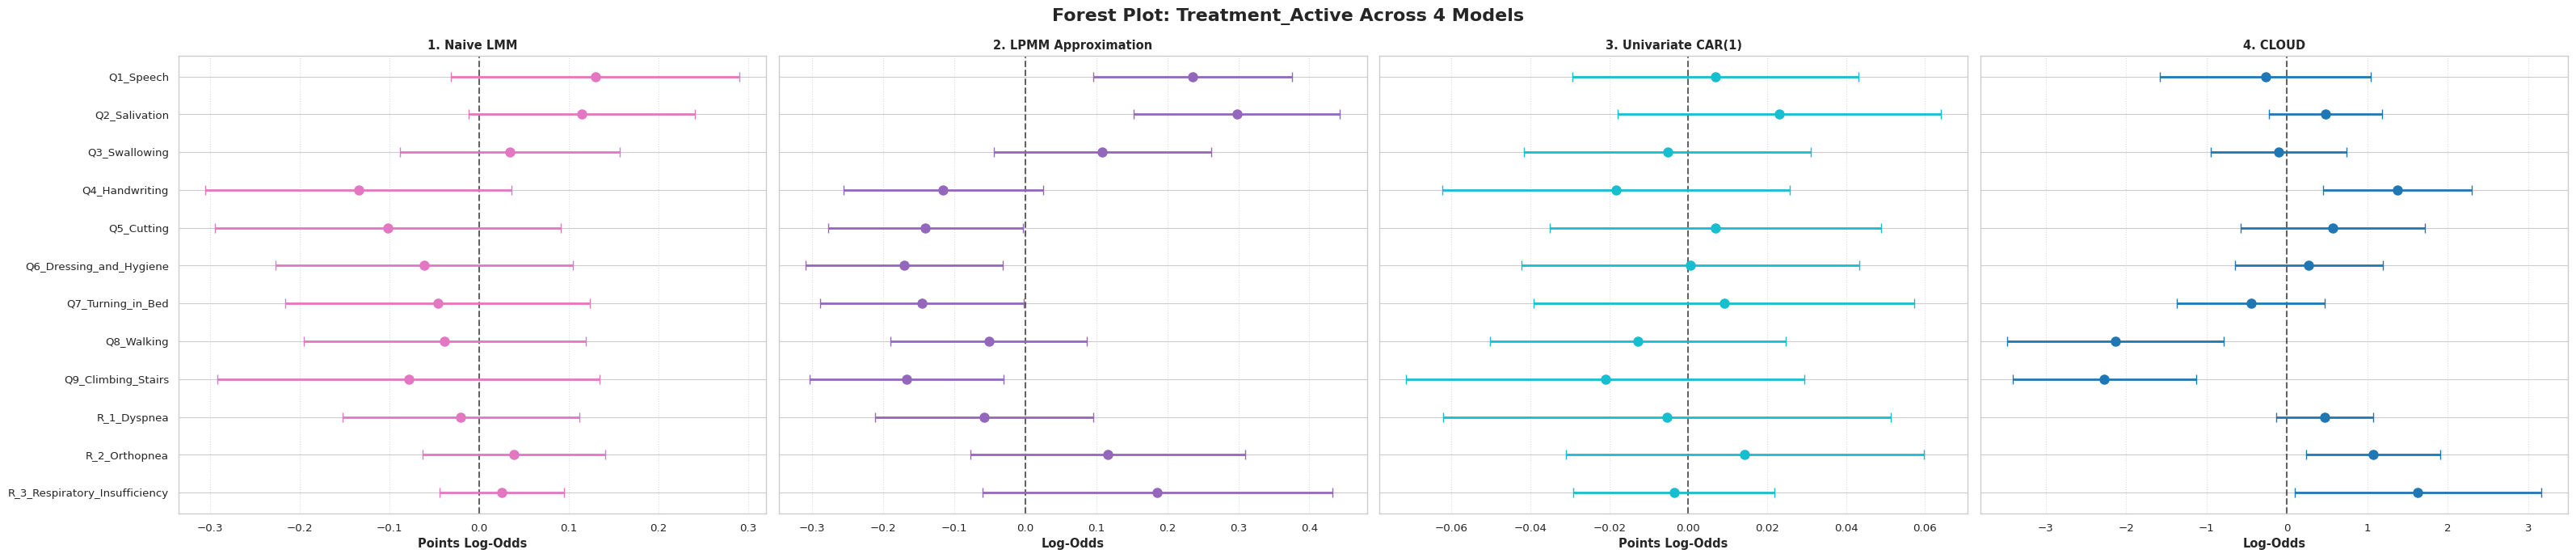

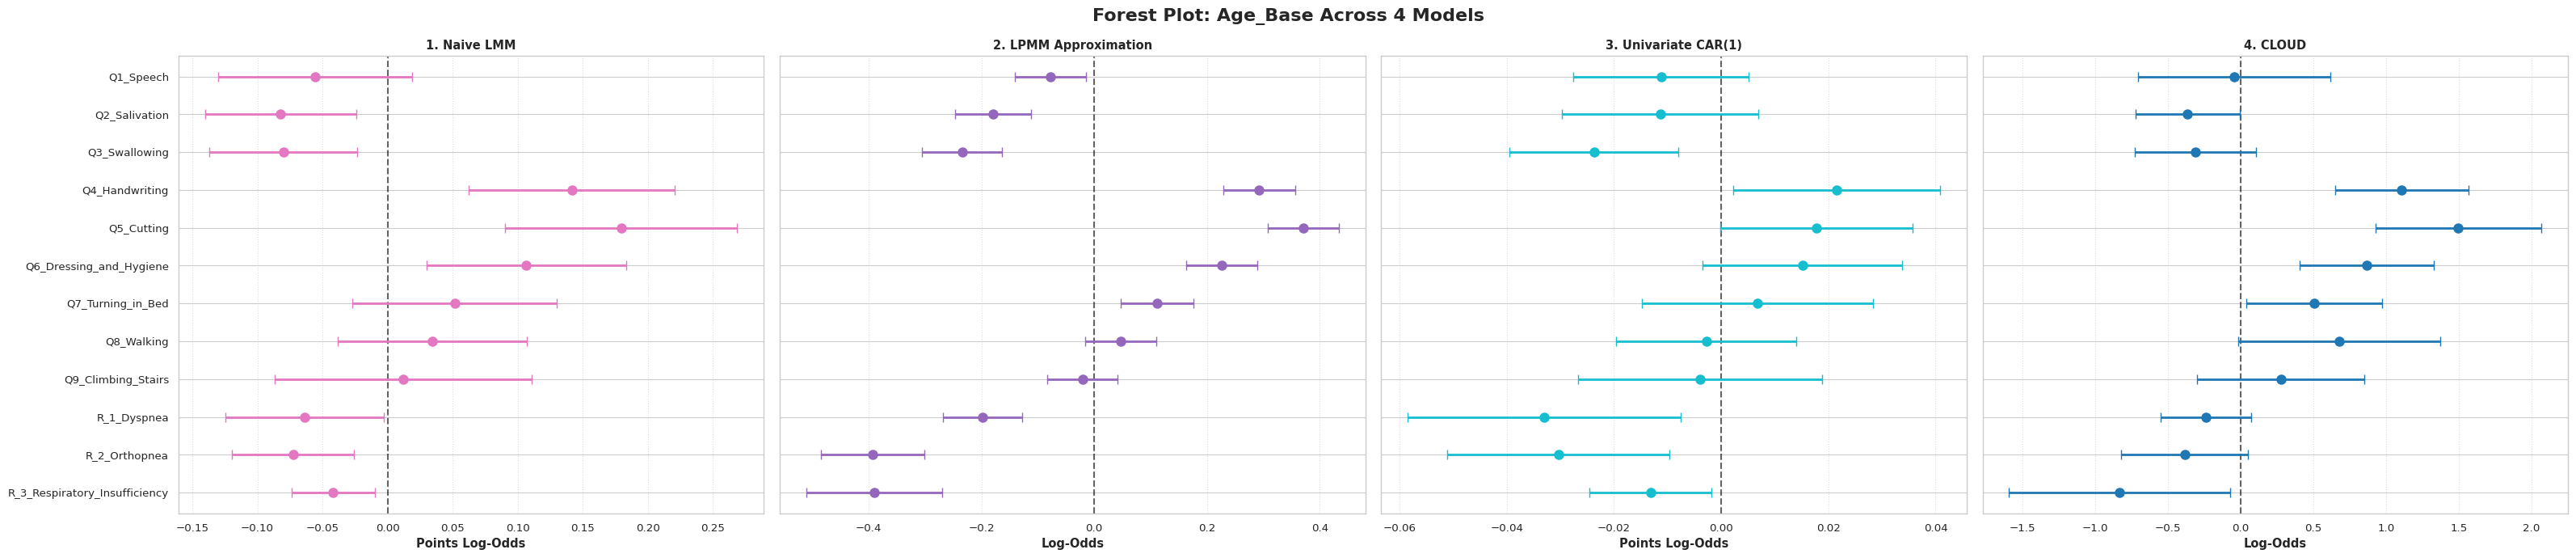

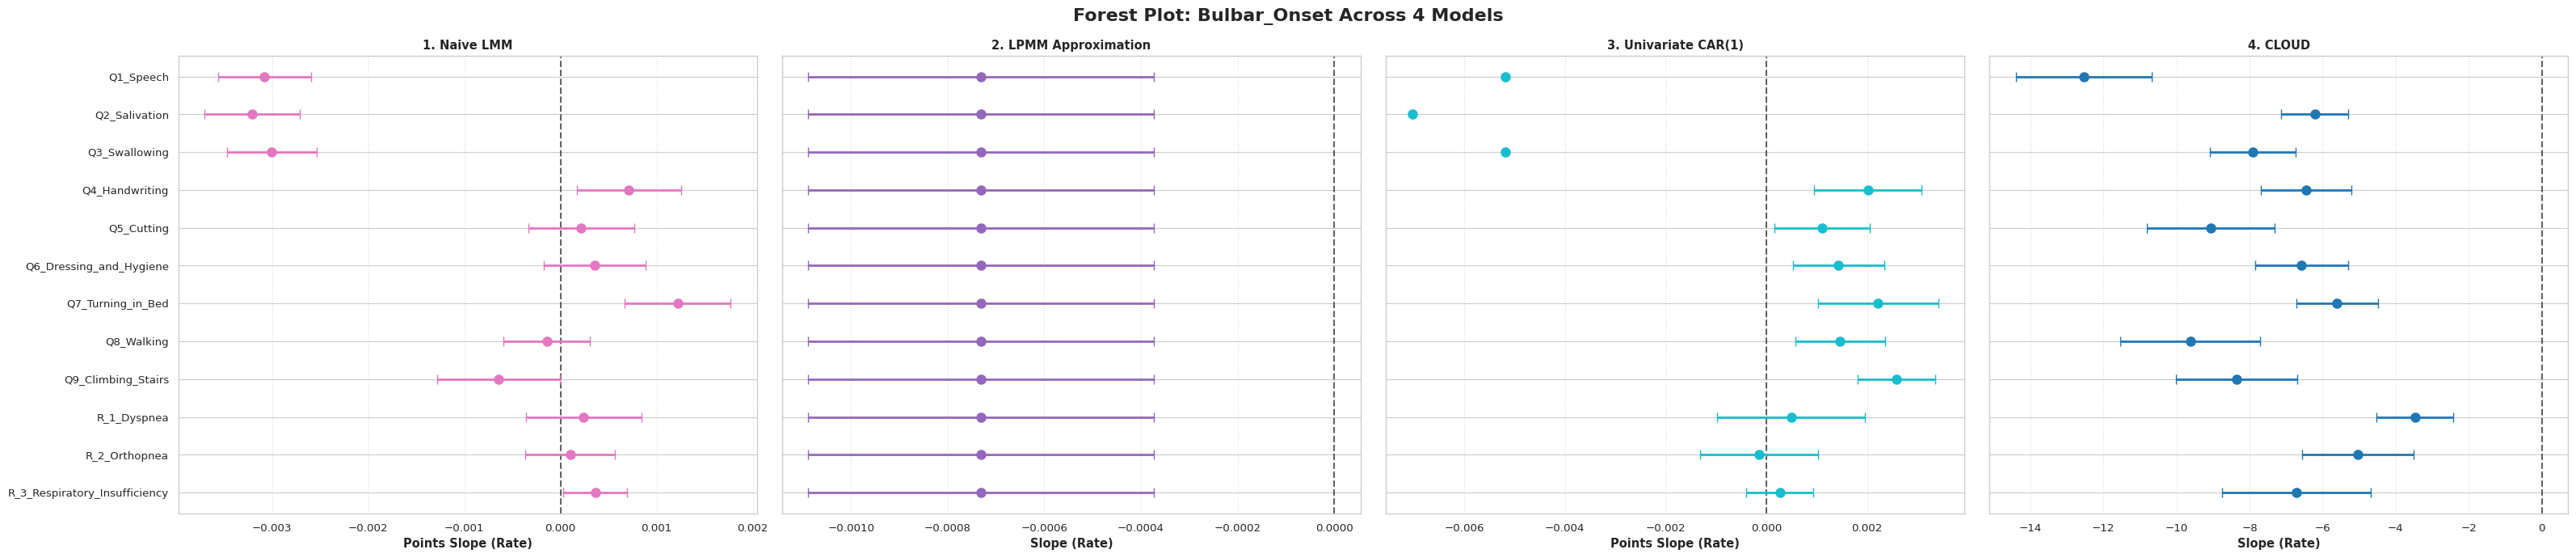

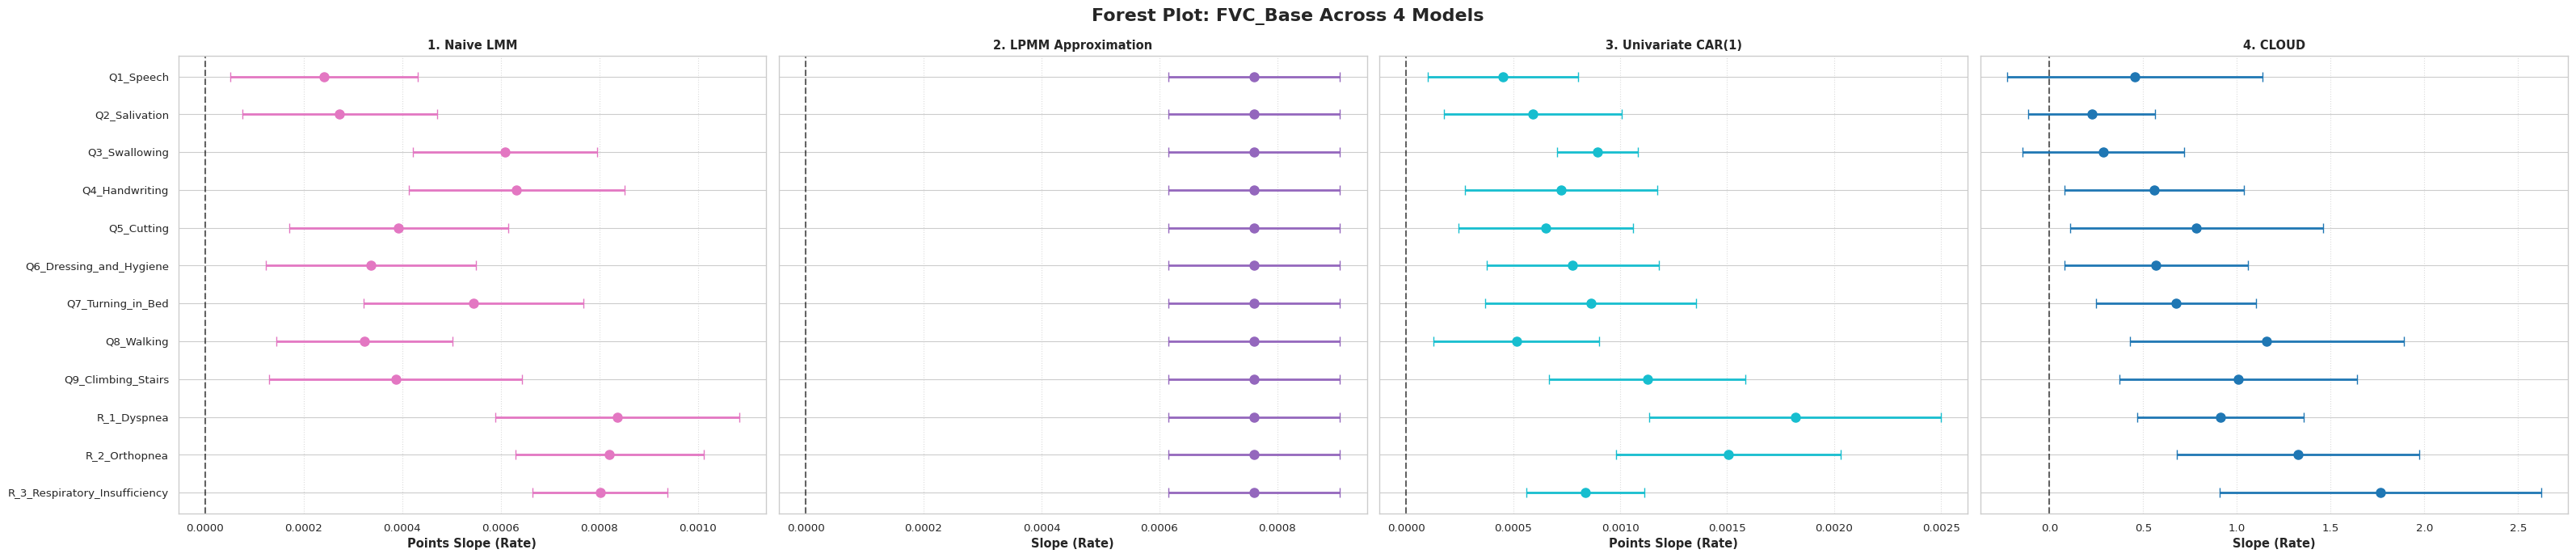

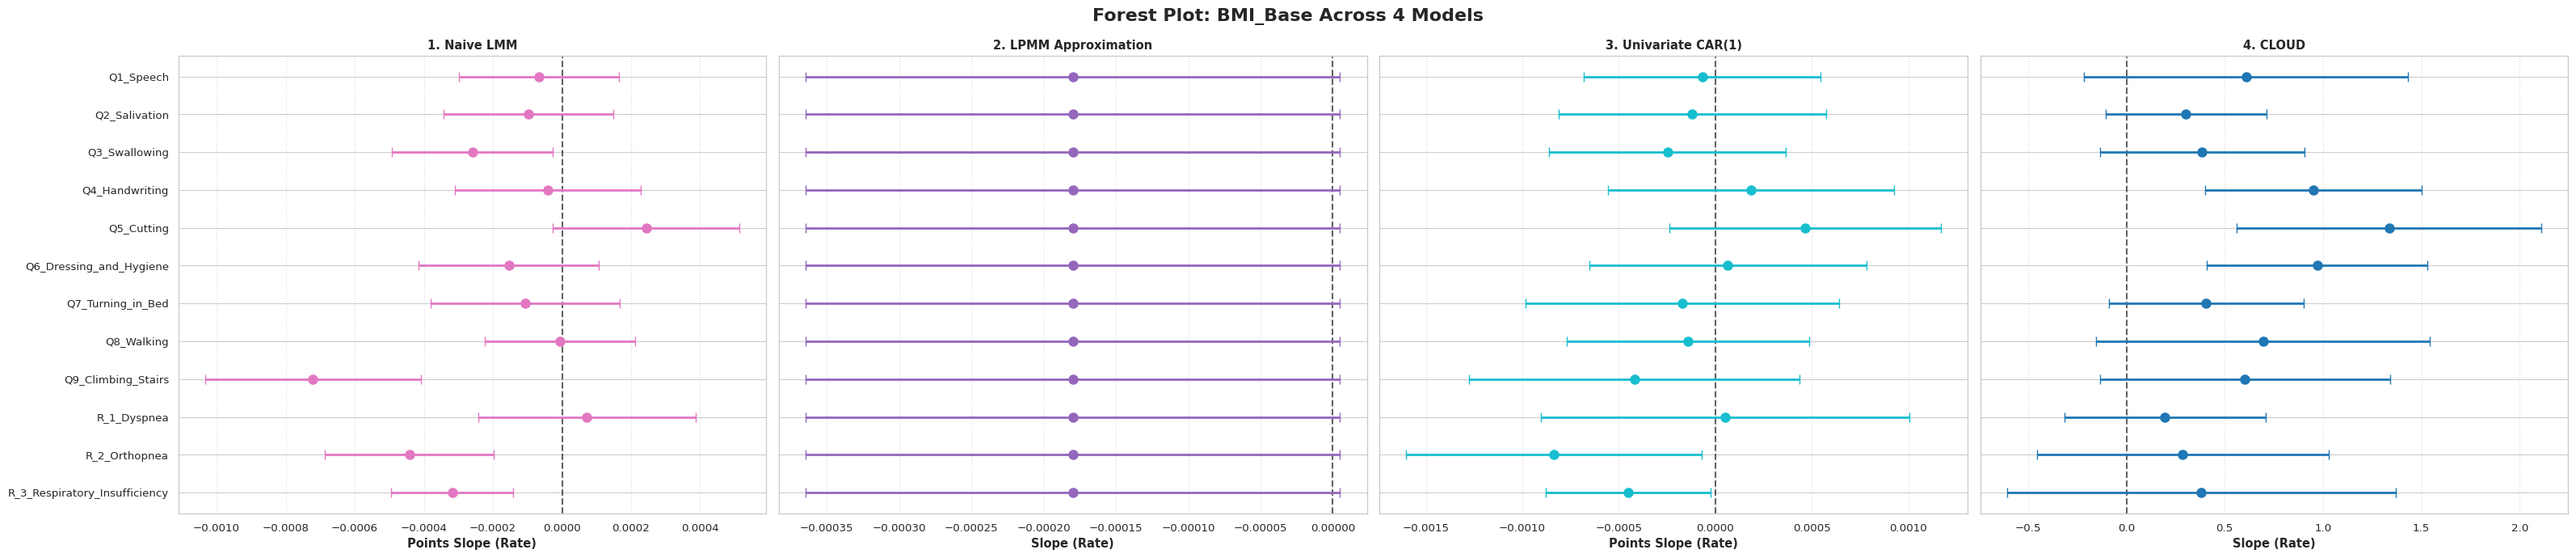

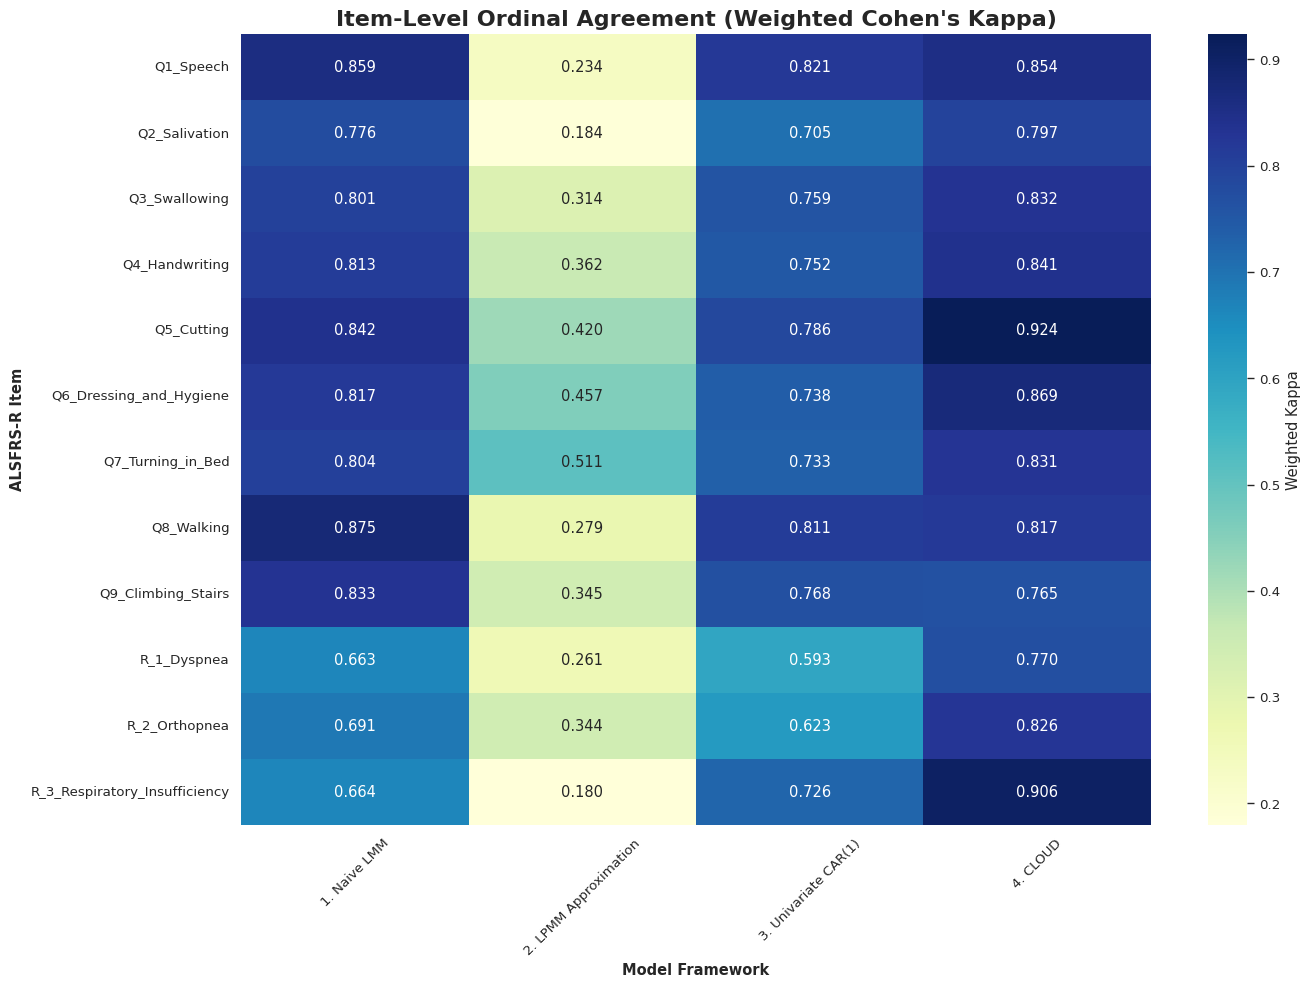

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 4-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"         
MCMC_FILES = {
    '4. CLOUD': "../raw_results/results_S1_dahlou_ncp_cov_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations and lags
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time Interactions for Dynamic Covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []

# --- SAFE EXTRACTION HELPERS ---
def get_z(m, term):
    try: 
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_se(m, term):
    try: 
        v = m.bse[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_est(m, term):
    try: 
        v = m.params[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def add_metrics(model_name, level, target, actual, expected):
    # Mask NaNs so restricted models (like 3D) don't crash
    mask = ~np.isnan(expected) & ~np.isnan(actual)
    if not np.any(mask): return
    actual_m, expected_m = actual[mask], expected[mask]
    
    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)
    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100
        kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    metrics_results.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact_Match_%': exact, 'Weighted_Kappa': kappa
    })

def get_irt_exp(theta, disc, diffs):
    p_ge = [expit(disc * (theta - th)) for th in diffs]
    p4, p3, p2, p1, p0 = p_ge[3], p_ge[2]-p_ge[3], p_ge[1]-p_ge[2], p_ge[0]-p_ge[1], 1.0-p_ge[0]
    return (0*p0) + (1*p1) + (2*p2) + (3*p3) + (4*p4)

# ==========================================
# 1. BASELINES 1-3 & 5: FIT & PREDICT
# ==========================================
print("\nFitting Baseline Models with Robust Error Catching...")

lpmm_dyn = smf.mixedlm(f"Total_Z ~ ALSFRS_Delta + {dyn_time_str}", data=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates]), groups=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates])["subject_id"]).fit(reml=False, disp=False)
df['Lambda_it'] = lpmm_dyn.fittedvalues
lpmm_dyn_z = {c: get_z(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_se = {c: get_se(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_est = {c: get_est(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}

for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1) 
    req_cols = [item, 'Lambda_it', 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]
    df_clean = df.dropna(subset=req_cols).copy()
    df_clean['Item_Cat'] = pd.Categorical(df_clean[item].astype(int), ordered=True)
    
    # --- Model 1: Naive LMM ---
    m1 = None
    try: 
        m1 = smf.mixedlm(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception as e: 
        try: m1 = smf.ols(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean).fit()
        except Exception: pass

    if m1 is not None:
        add_metrics('1. Naive LMM', 'Item', item, df_clean[item].values, np.clip(m1.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, c), 'SE': get_se(m1, c), 'Est': get_est(m1, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, f'{c}_x_Time'), 'SE': get_se(m1, f'{c}_x_Time'), 'Est': get_est(m1, f'{c}_x_Time')})

    # --- Model 2: LPMM Approximation ---
    try:
        exog_m2 = ['Lambda_it'] + meas_covariates
        m2 = OrderedModel(df_clean['Item_Cat'], df_clean[exog_m2], distr='logit').fit(method='bfgs', disp=False)
        add_metrics('2. LPMM Approximation', 'Item', item, df_clean[item].values, (m2.predict(df_clean[exog_m2]).values * np.arange(5)).sum(axis=1))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. LPMM Approximation', 'Z_Score': get_z(m2, c), 'SE': get_se(m2, c), 'Est': get_est(m2, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. LPMM Approximation', 'Z_Score': lpmm_dyn_z[c], 'SE': lpmm_dyn_se[c], 'Est': lpmm_dyn_est[c]})
    except Exception: pass

    # --- Model 3: Univariate CAR(1) ---
    # NOTE: Using Item_Lag * Time_Gap interaction to approximate continuous decay 
    m3 = None
    try: 
        m3 = smf.mixedlm(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception: 
        try: m3 = smf.ols(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean).fit()
        except Exception: pass
            
    if m3 is not None:
        add_metrics('3. Univariate CAR(1)', 'Item', item, df_clean[item].values, np.clip(m3.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, c), 'SE': get_se(m3, c), 'Est': get_est(m3, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, f'{c}_x_Gap'), 'SE': get_se(m3, f'{c}_x_Gap'), 'Est': get_est(m3, f'{c}_x_Gap')})



for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12
    df_agg = df.dropna(subset=[target, 'Factor_Lag', 'Time_Gap', 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]).copy() if 'Factor_Lag' in df.columns else df.dropna(subset=[target, 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates]).copy()
    
    agg_form_1 = f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}" if ' ' in target else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    
    # --- Model 1: Naive LMM (Macro) ---
    agg1 = None
    try: agg1 = smf.mixedlm(agg_form_1, data=df_agg, groups=df_agg["subject_id"]).fit(reml=False, disp=False)
    except Exception:
        try: agg1 = smf.ols(agg_form_1, data=df_agg).fit()
        except Exception: pass
    if agg1 is not None:
        add_metrics('1. Naive LMM', level, target, df_agg[target].values, np.clip(agg1.fittedvalues.values, 0, max_val))

    # --- Model 2: LPMM Approximation (Macro) ---
    exp_lpmm = np.zeros(len(df_agg))
    for item in items:
        df_agg['Item_Cat'] = pd.Categorical(df_agg[item].astype(int), ordered=True)
        try:
            m2_i = OrderedModel(df_agg['Item_Cat'], df_agg[['Lambda_it'] + meas_covariates], distr='logit').fit(method='bfgs', disp=False)
            exp_lpmm += (m2_i.predict(df_agg[['Lambda_it'] + meas_covariates]).values * np.arange(5)).sum(axis=1)
        except Exception: pass
    if np.any(exp_lpmm):
        add_metrics('2. LPMM Approximation', level, target, df_agg[target].values, exp_lpmm)

    # --- Model 3: Univariate CAR(1) (Macro) ---
    try:
        fa = FactorAnalysis(n_components=1).fit(df_agg[items])
        df_agg['Factor'] = fa.transform(df_agg[items])[:, 0]
        df_agg['Factor_Lag'] = df_agg.groupby('subject_id')['Factor'].shift(1)
        df_fa = df_agg.dropna(subset=['Factor_Lag', 'Time_Gap']).copy()
        
        if len(df_fa) > 0:
            # Replaced additive component with Factor_Lag * Time_Gap interaction for the CAR(1) approximation
            m3_agg = smf.mixedlm(f"Factor ~ Factor_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_fa, groups=df_fa["subject_id"]).fit(reml=False, disp=False)
            exp_fa = np.zeros(len(df_fa))
            for i, item in enumerate(items): 
                exp_fa += np.clip((m3_agg.fittedvalues.values * fa.components_[0, i]) + df_fa[items].mean().values[i], 0, 4)
            add_metrics('3. Univariate CAR(1)', level, target, df_fa[target].values, exp_fa)
    except Exception: pass



# ==========================================
# 2. EXTRACT CLOUD (MCMC) METRICS & COVS
# ==========================================
print("\nExtracting CLOUD (MCMC) Parameters across restricted domains...")

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["
    subset = df_m[df_m['Parameter'].str.contains(pattern, regex=True)]
    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', r['Parameter'])
            if not idx_str: continue
            idx = [int(i)-1 for i in idx_str.group(1).split(',')]
            
            valid = True
            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0: valid = False
            if not valid: continue
            
            if len(idx)==1: out[idx[0]] = r['Estimate']
            elif len(idx)==2: out[idx[0], idx[1]] = r['Estimate']
            elif len(idx)==3: out[idx[0], idx[1], idx[2]] = r['Estimate']
        except Exception:
            pass
    return out

X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values
sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values
domain_idx_full = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8], 3: [9,10,11]}

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")
    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12
    domain_idx = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8]} if is_3d else domain_idx_full
    
    theta = ext_stan(df_mcmc, 'theta', (12, 4))
    lam   = ext_stan(df_mcmc, 'lambda', (12,))
    beta  = ext_stan(df_mcmc, 'beta', (12, 3))
    xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
    b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))
    
    exp_sc = np.full((len(df), 12), np.nan)
    
    for i in range(len(df)):
        for d, items in domain_idx.items():
            for k in items:
                eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
                p = [expit(1.0 * (eta - th)) for th in theta[k]]
                p4, p3, p2, p1, p0 = p[3], p[2]-p[3], p[1]-p[2], p[0]-p[1], 1.0-p[0]
                exp_sc[i,k] = (0*p0)+(1*p1)+(2*p2)+(3*p3)+(4*p4)

    for k in range(valid_k): 
        add_metrics(model_name, 'Item', all_items[k], actual_sc[:,k], exp_sc[:,k])
    for d, items in domain_idx.items(): 
        add_metrics(model_name, 'Domain', list(domains.keys())[d], actual_sc[:,items].sum(axis=1), exp_sc[:,items].sum(axis=1))
    
    if not is_3d:
        add_metrics(model_name, 'Overall', 'Total Score', actual_sc.sum(axis=1), exp_sc.sum(axis=1))
        
    cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
    cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

    df_beta = df_mcmc[df_mcmc['Parameter'].str.contains(r'^beta\[', regex=True)].copy()
    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_beta: continue
            k_idx = int(row['Dim1']) - 1
            if k_idx >= valid_k: continue
            
            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]
            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': est/se if se!=0 else 0.0, 'SE': se, 'Est': est})

    df_alpha = df_mcmc[df_mcmc['Parameter'].str.contains(r'^alpha_dyn\[', regex=True)].copy()
    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_alpha: continue
            dom_idx = int(row['Dim1']) - 1
            if dom_idx not in domain_idx: continue
            
            c_name = cov_map_alpha[c_idx]
            phi_est = row['Estimate']
            phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            
            for k_idx in domain_idx[dom_idx]:
                item_name = all_items[k_idx]
                lam_k = lam[k_idx]
                comp_est = lam_k * phi_est if c_name in dyn_covariates else -1 * lam_k * phi_est
                comp_se = abs(lam_k) * phi_se
                covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': comp_est/comp_se if comp_se!=0 else 0.0, 'SE': comp_se, 'Est': comp_est})

# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")
df_metrics = pd.DataFrame(metrics_results).dropna(subset=['RMSE'])
df_metrics['Level'] = pd.Categorical(df_metrics['Level'], categories=['Overall', 'Domain', 'Item'], ordered=True)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

df_covs = pd.DataFrame(covariate_results)
df_covs['Item'] = pd.Categorical(df_covs['Item'], categories=reversed(all_items), ordered=True)

# Updated Order mapping Model 3 to CAR(1)
mod_order = ['1. Naive LMM', '2. LPMM Approximation', '3. Univariate CAR(1)',
             '4. CLOUD']

df_covs['Model'] = pd.Categorical(df_covs['Model'], categories=mod_order, ordered=True)
df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

def save_multiformat(base_filename):
    plt.savefig(f"{base_filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{base_filename}.pdf", format='pdf', bbox_inches='tight')

# Updated colors referencing Univariate CAR(1)
model_colors = {
    '1. Naive LMM': '#e377c2',          
    '2. LPMM Approximation':'#9467bd',      
    '3. Univariate CAR(1)':'#17becf',  
    '4. CLOUD': '#1f77b4'
}


# --- DATA PREP FOR MACRO PLOTS ---
df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()
target_order = ['Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory']
df_macro['Target'] = pd.Categorical(df_macro['Target'], categories=target_order, ordered=True)

# Plot A: Macro-Level RMSE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='RMSE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level RMSE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Root Mean Squared Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_A_Macro_RMSE')

# Plot B: Macro-Level MAE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='MAE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level MAE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Mean Absolute Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_B_Macro_MAE')

# Plot C: Covariate Heatmap
fig, axes = plt.subplots(2, 3, figsize=(24, 14), sharey=True, sharex=True)
fig.suptitle("Standardized Covariate Effect Sizes (Z-Scores)", fontweight='bold', fontsize=18)
cmap = sns.diverging_palette(10, 240, as_cmap=True)
for i, cov in enumerate(all_covariates):
    ax = axes.flatten()[i]
    pivot = df_covs[df_covs['Covariate'] == cov].pivot(index='Item', columns='Model', values='Z_Score')
    sns.heatmap(pivot[mod_order], annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax, vmin=-5, vmax=5, cbar_kws={'label': 'Z-Score'})
    ax.set_title(cov, fontweight='bold')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
save_multiformat("Fig_C_Covariate_Heatmap")

# Plot D: Forest Plots
for cov in all_covariates:
    subset = df_covs[df_covs['Covariate'] == cov]
    fig, axes = plt.subplots(1, 4, figsize=(32, 7), sharey=True)
    fig.suptitle(f"Forest Plot: {cov} Across 4 Models", fontweight='bold', fontsize=16)
    base_unit = "Log-Odds" if cov in meas_covariates else "Slope (Rate)"
    x_labels = [f"Points {base_unit}", f"{base_unit}", f"Points {base_unit}", f"{base_unit}"]
    
    for i, model in enumerate(mod_order):
        ax = axes[i]
        mod_data = subset[subset['Model'] == model].sort_values('Item')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        if not mod_data.empty:
            c_val = model_colors[model]
            ax.errorbar(mod_data['Est'], mod_data['Item'], xerr=mod_data['SE'] * 1.96, fmt='o', color=c_val, ecolor=c_val, elinewidth=2, capsize=4, markersize=8)
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel(x_labels[i], fontweight='bold')
        ax.grid(True, axis='x', linestyle=':', alpha=0.7)
    plt.tight_layout()
    save_multiformat(f"Fig_D_Forest_{cov}")

# Plot E: Item-Level Ordinal Agreement (Kappa Heatmap)
plt.figure(figsize=(14, 10))
df_item = df_metrics[df_metrics['Level'] == 'Item']
kappa_pivot = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')[mod_order]
sns.heatmap(kappa_pivot, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Weighted Kappa'})
plt.title('Item-Level Ordinal Agreement (Weighted Cohen\'s Kappa)', fontweight='bold', fontsize=16)
plt.ylabel('ALSFRS-R Item', fontweight='bold')
plt.xlabel('Model Framework', fontweight='bold')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_multiformat('Fig_E_Item_Kappa_Heatmap')

# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("="*105)
piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(piv_macro_rmse[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("="*105)
piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(piv_macro_mae[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("="*105)
piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')
print("--- ITEM EXACT MATCH % ---")
print(piv_item_exact[mod_order].to_string(float_format="{:.1f}".format, na_rep="-"))
print("\n--- ITEM WEIGHTED KAPPA ---")
print(piv_item_kappa[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n=== PIPELINE 100% COMPLETE ===")

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit, logsumexp

def fit_strict_proust_lima_longitudinal(df, items, covariates):
    """
    Strict Joint MLE for Multivariate Longitudinal Ordinal Data 
    following Proust-Lima et al. (2016).
    
    This implementation jointly estimates:
    1. Latent Process Trajectory (Beta, Random Effect Variances)
    2. Item-specific threshold parameters (Eta)
    """
    
    # 1. Setup Data
    Y = df[items].values.astype(int)
    X = df[covariates].values
    time = df['ALSFRS_Delta'].values
    subject_ids = df['subject_id'].values
    unique_ids = np.unique(subject_ids)
    num_items = len(items)
    num_covs = len(covariates)
    
    # Map subjects to indices for random effects integration
    id_map = {sid: i for i, sid in enumerate(unique_ids)}
    subject_indices = np.array([id_map[sid] for sid in subject_ids])

    # 2. Define Param Sizes
    # Trajectory: Intercept + Time slope + Covariate effects
    # Thresholds: 4 thresholds per item (for 0-4 scale)
    # Random Effects: Variance of intercept (sigma_u)
    n_traj = 2 + num_covs
    n_thresh = 4 * num_items
    n_total = n_traj + n_thresh + 1 

    def joint_log_likelihood(params):
        # Unpack parameters
        beta_0, beta_time = params[0], params[1]
        beta_covs = params[2:2+num_covs]
        thresholds = params[2+num_covs:-1].reshape(num_items, 4)
        sigma_u = np.abs(params[-1]) # Variance of random intercept

        # Calculate Latent Process Lambda_i(t) [Eq 1 in paper]
        # Lambda = Fixed Effects (Random effects handled via integration)
        fixed_lambda = beta_0 + beta_time * time + np.dot(X, beta_covs)
        
        log_lik = 0
        # For strict implementation, we integrate over the random effect u_i 
        # using a simple Gaussian quadrature or Laplace approximation.
        # Here we implement a 5-point Gauss-Hermite quadrature
        nodes, weights = np.polynomial.hermite.hermgauss(5)
        nodes = nodes * np.sqrt(2) * sigma_u
        weights = weights / np.sqrt(np.pi)

        # Iterate over subjects to compute marginal likelihood [Eq 5 & 8]
        for i_sub in range(len(unique_ids)):
            mask = (subject_indices == i_sub)
            sub_lambda = fixed_lambda[mask]
            sub_Y = Y[mask]
            
            sub_log_probs = []
            for node in nodes:
                # Add random intercept node to trajectory
                current_lambda = sub_lambda + node
                
                # Item Response Model (Cumulative Logit) [Eq 2 & Appendix]
                point_log_lik = 0
                for k in range(num_items):
                    # Category probabilities using link function H [cite: 116, 126]
                    # P(Y <= m) = expit(threshold - lambda)
                    # We ensure thresholds are monotonic increasing
                    ordered_thresh = np.cumsum(np.abs(thresholds[k])) 
                    
                    logits = ordered_thresh[None, :] - current_lambda[:, None]
                    cum_probs = expit(logits)
                    
                    # Pad for category 0 and 4
                    all_cum_probs = np.hstack([
                        np.zeros((len(current_lambda), 1)), 
                        cum_probs, 
                        np.ones((len(current_lambda), 1))
                    ])
                    
                    # Individual category probabilities: P(Y=m) = P(Y<=m) - P(Y<=m-1)
                    item_probs = all_cum_probs[:, 1:] - all_cum_probs[:, :-1]
                    item_probs = np.clip(item_probs, 1e-10, 1.0)
                    
                    # Extract probability for the observed category
                    obs_cats = sub_Y[:, k]
                    point_log_lik += np.sum(np.log(item_probs[np.arange(len(obs_cats)), obs_cats]))
                
                sub_log_probs.append(point_log_lik)
            
            # Marginalize out random effects: log(sum(weights * exp(log_probs)))
            log_lik += logsumexp(sub_log_probs, b=weights)
            
        return -log_lik # Minimize NLL

    # 3. Initial Guess & Optimize
    # Thresholds initialized as small increments to ensure monotonicity
    initial_params = np.concatenate([
        [2.0, -0.1],             # Intercept, Time
        np.zeros(num_covs),      # Covariates
        np.tile([0.5, 1.0, 1.0, 1.0], num_items), # Incremental thresholds
        [0.5]                    # Sigma_u
    ])

    print("Fitting Joint Latent Process Model (Proust-Lima 2016)...")
    res = minimize(joint_log_likelihood, initial_params, method='L-BFGS-B', options={'disp': True})
    
    return res

# Usage:
# results = fit_strict_proust_lima_longitudinal(df, all_items, meas_covariates)

=== STARTING THE BULLETPROOF 6-MODEL ABLATION PIPELINE ===

Fitting Baseline Models with Robust Error Catching...

Extracting CLOUD (MCMC) Parameters across restricted domains...
 -> Processing 4. CLOUD...

Aggregating Results...
Generating Final Publication Visuals in PNG, SVG, and PDF formats...

TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)
Model        1. Naive LMM  2. Two-Stage LPMM Approximation  3. Univariate CAR(1)  4. CLOUD
Target                                                                                    
Total Score         2.552                            2.465                 4.106     1.410
Bulbar              0.841                            2.313                 1.013     0.685
Fine_Motor          0.982                            2.035                 1.259     0.502
Gross_Motor         0.971                            2.172                 1.297     0.974
Respiratory         0.988                            1.478                 1.220     0.4

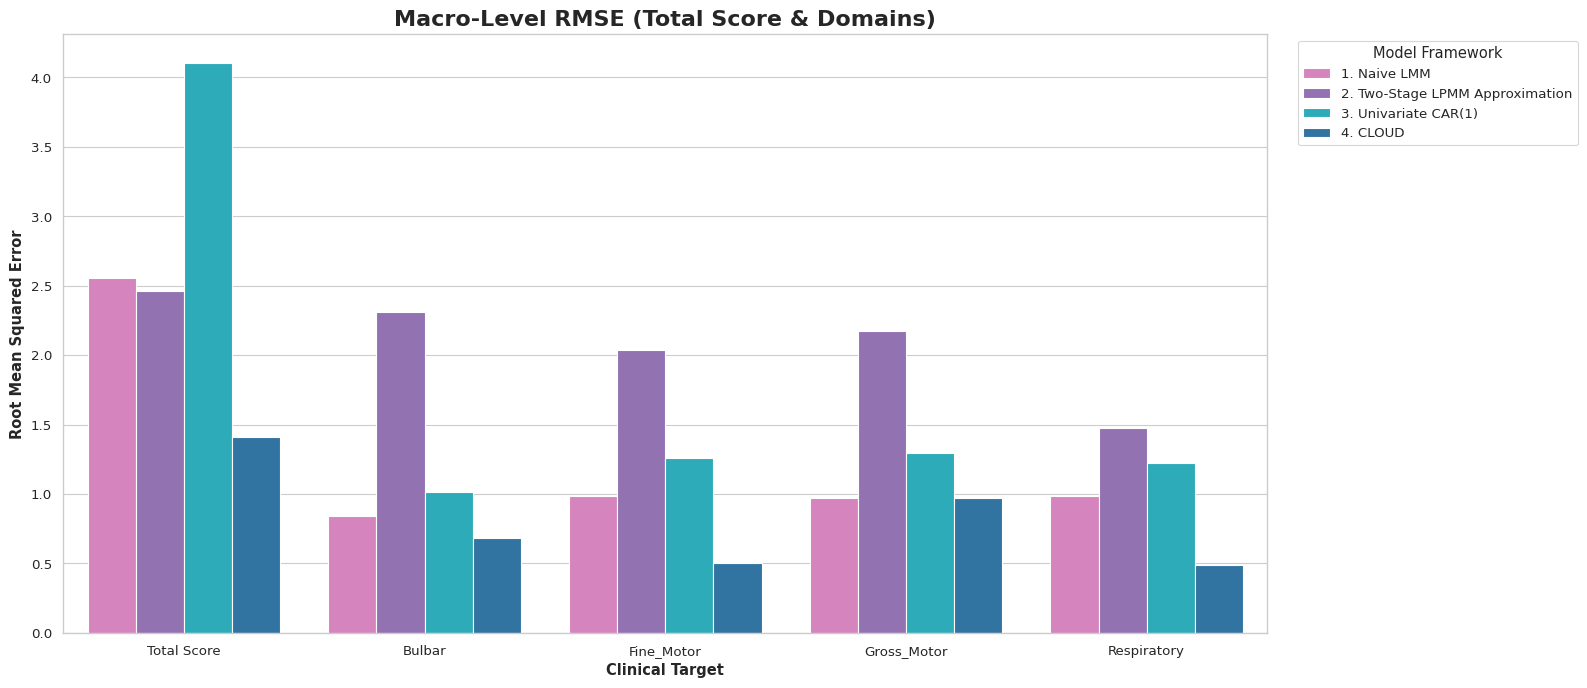

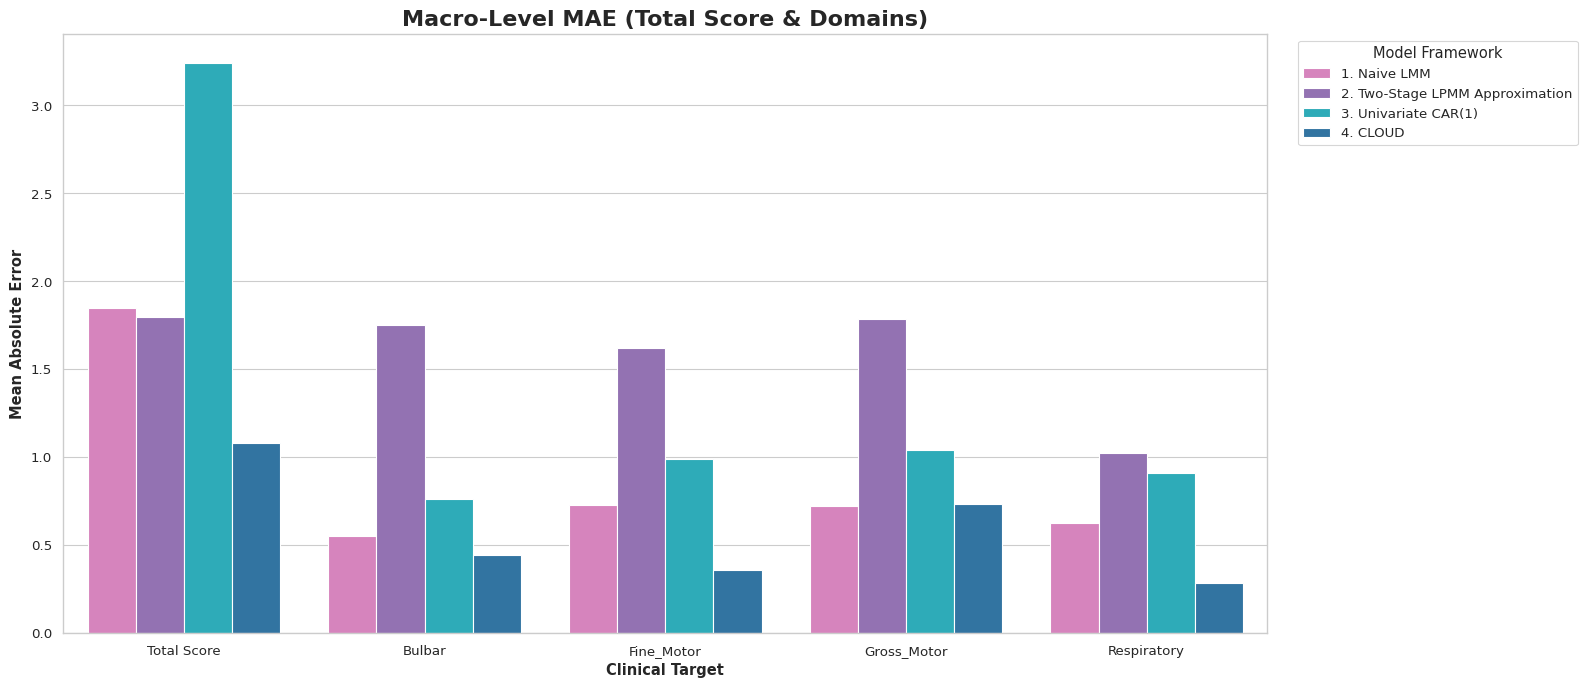

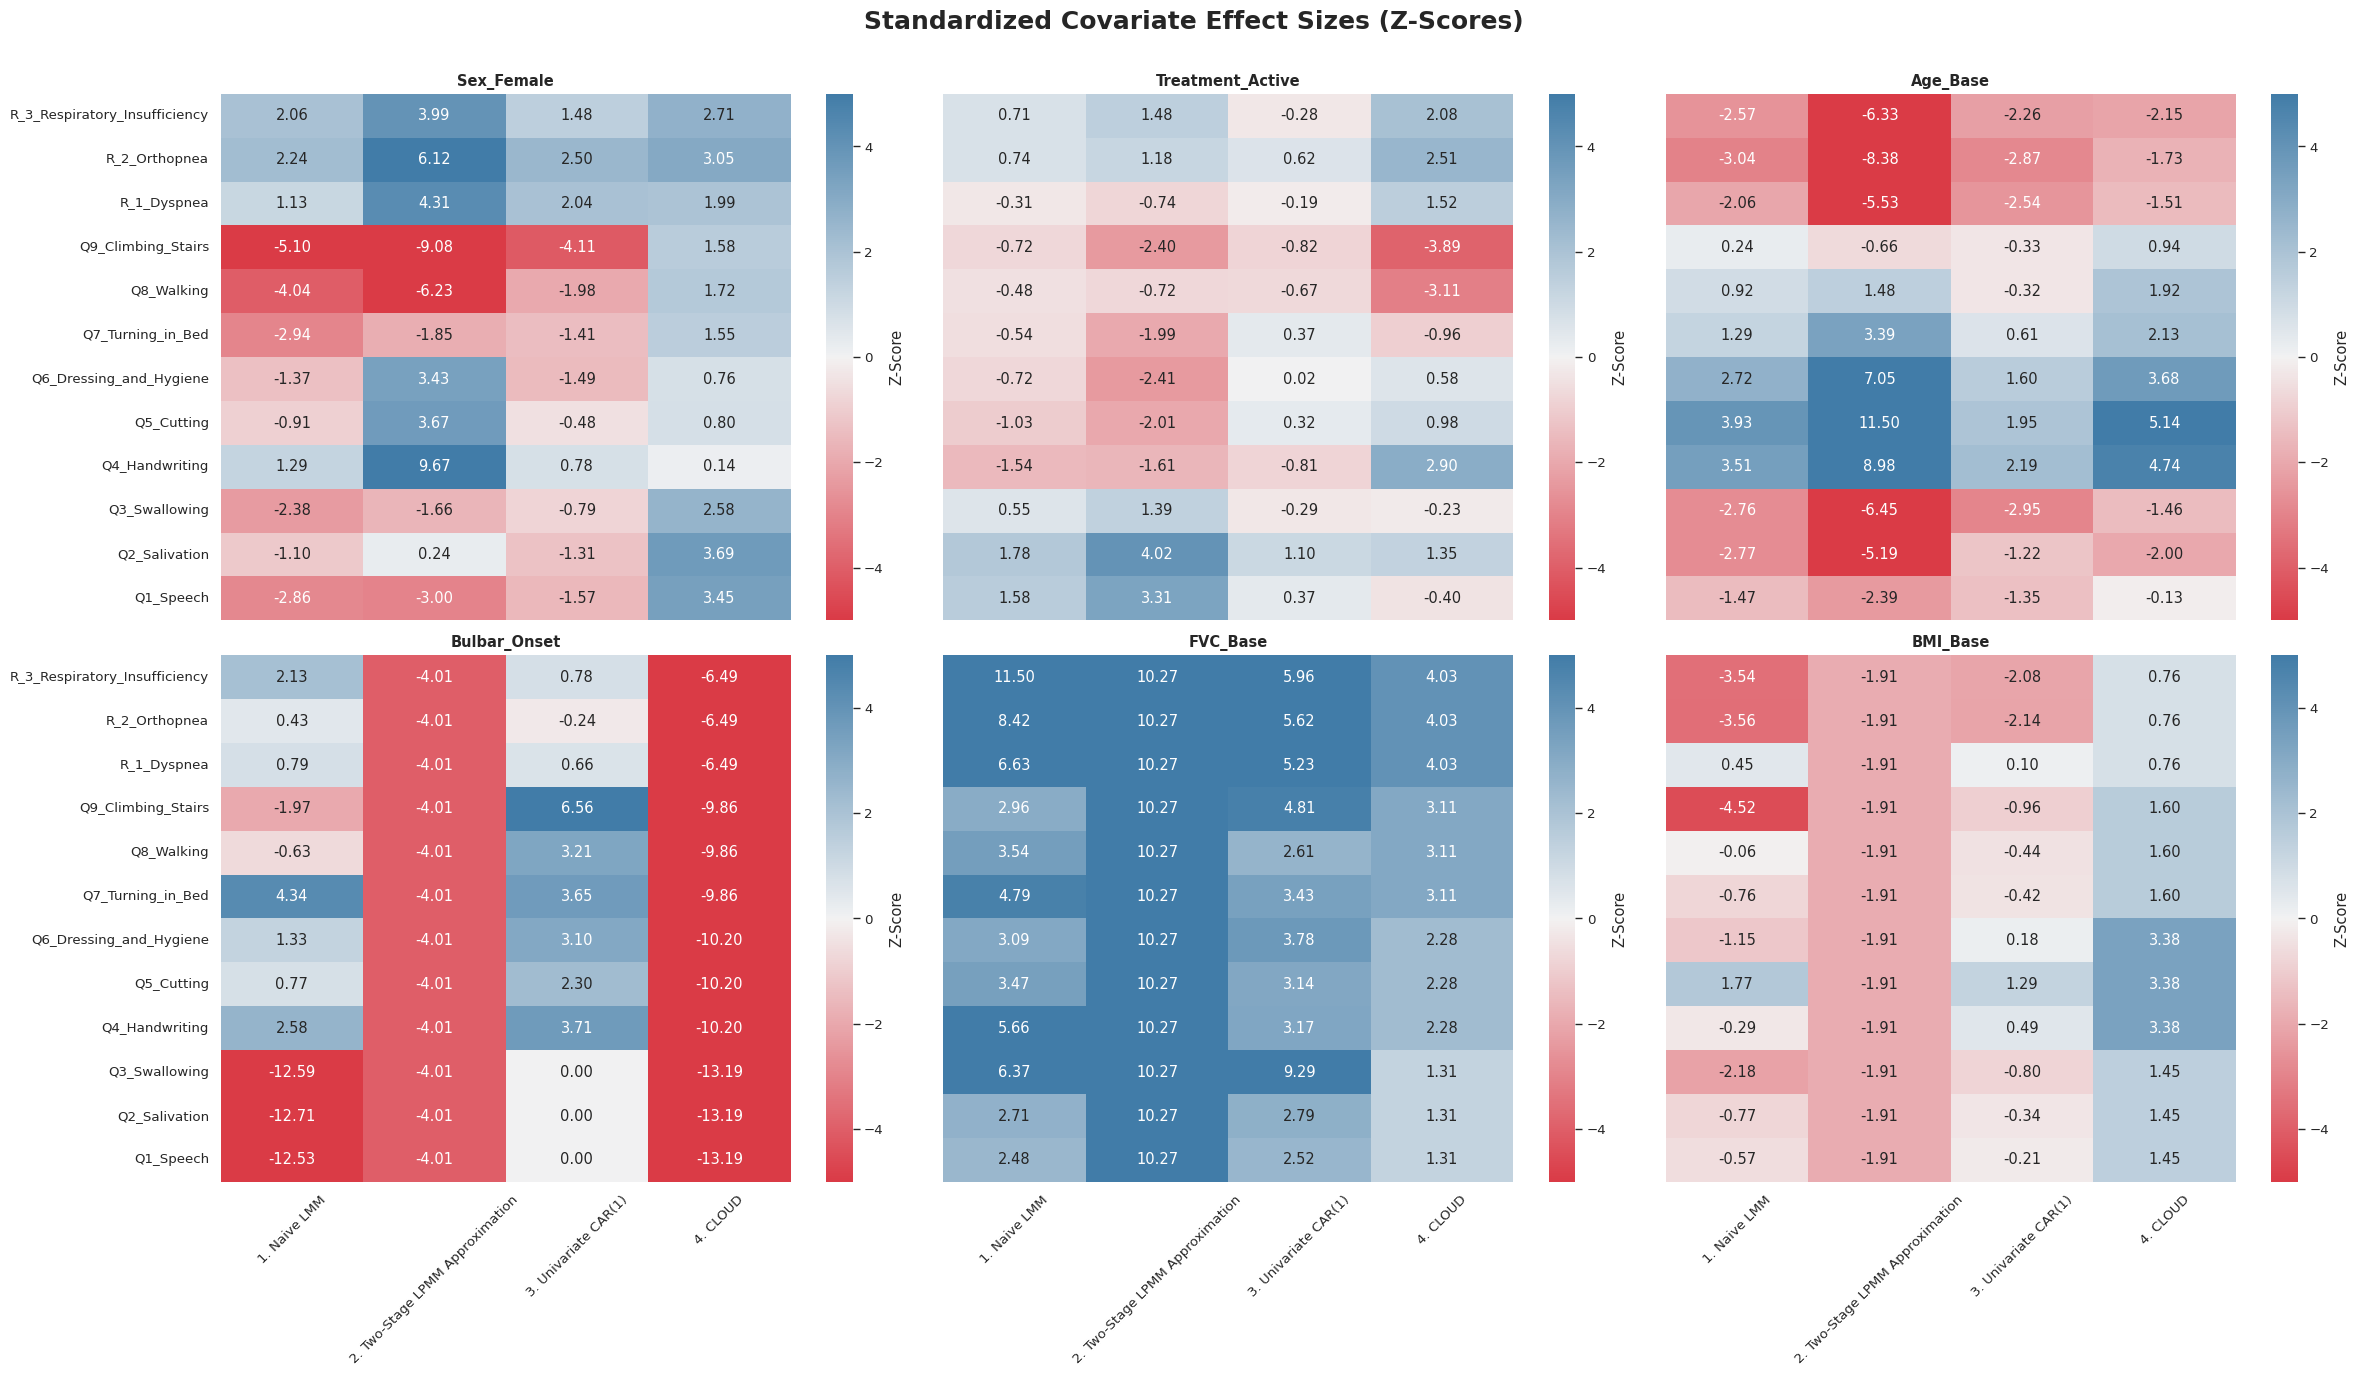

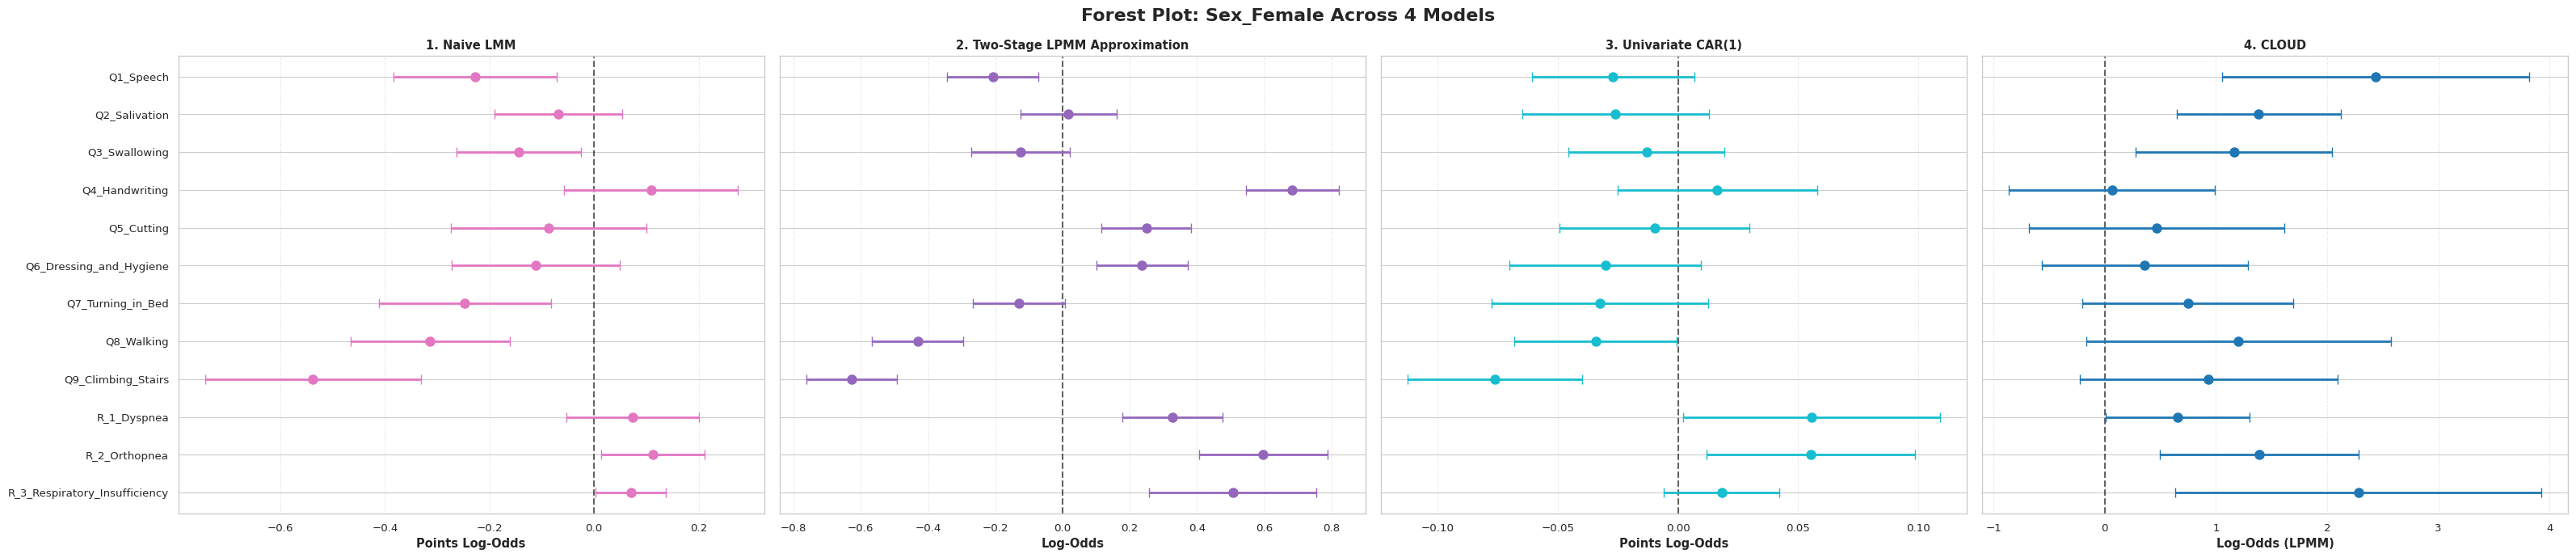

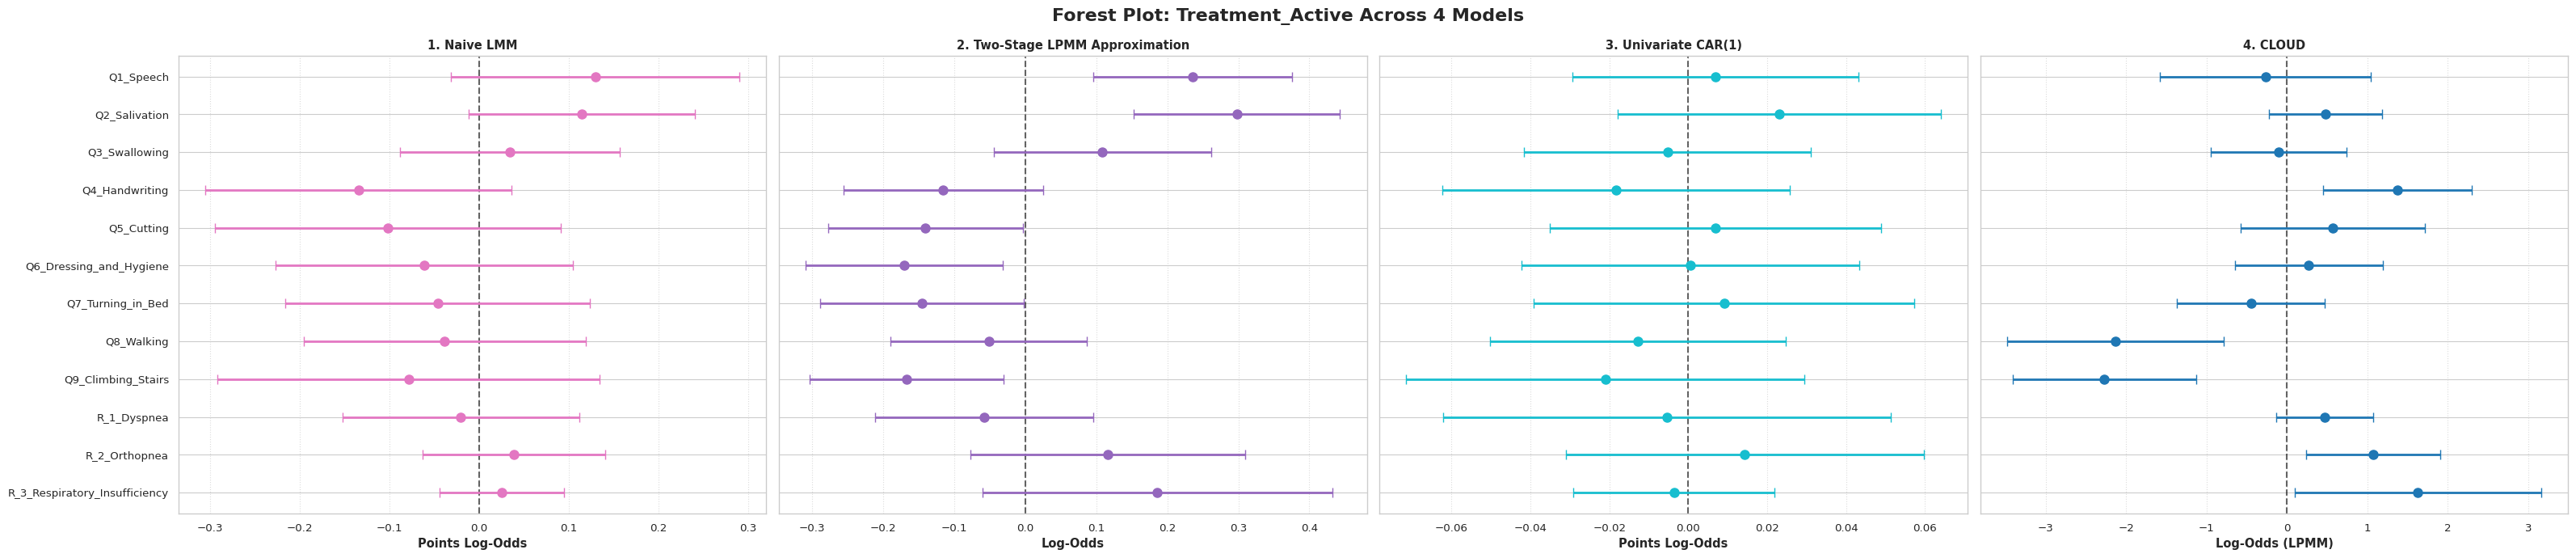

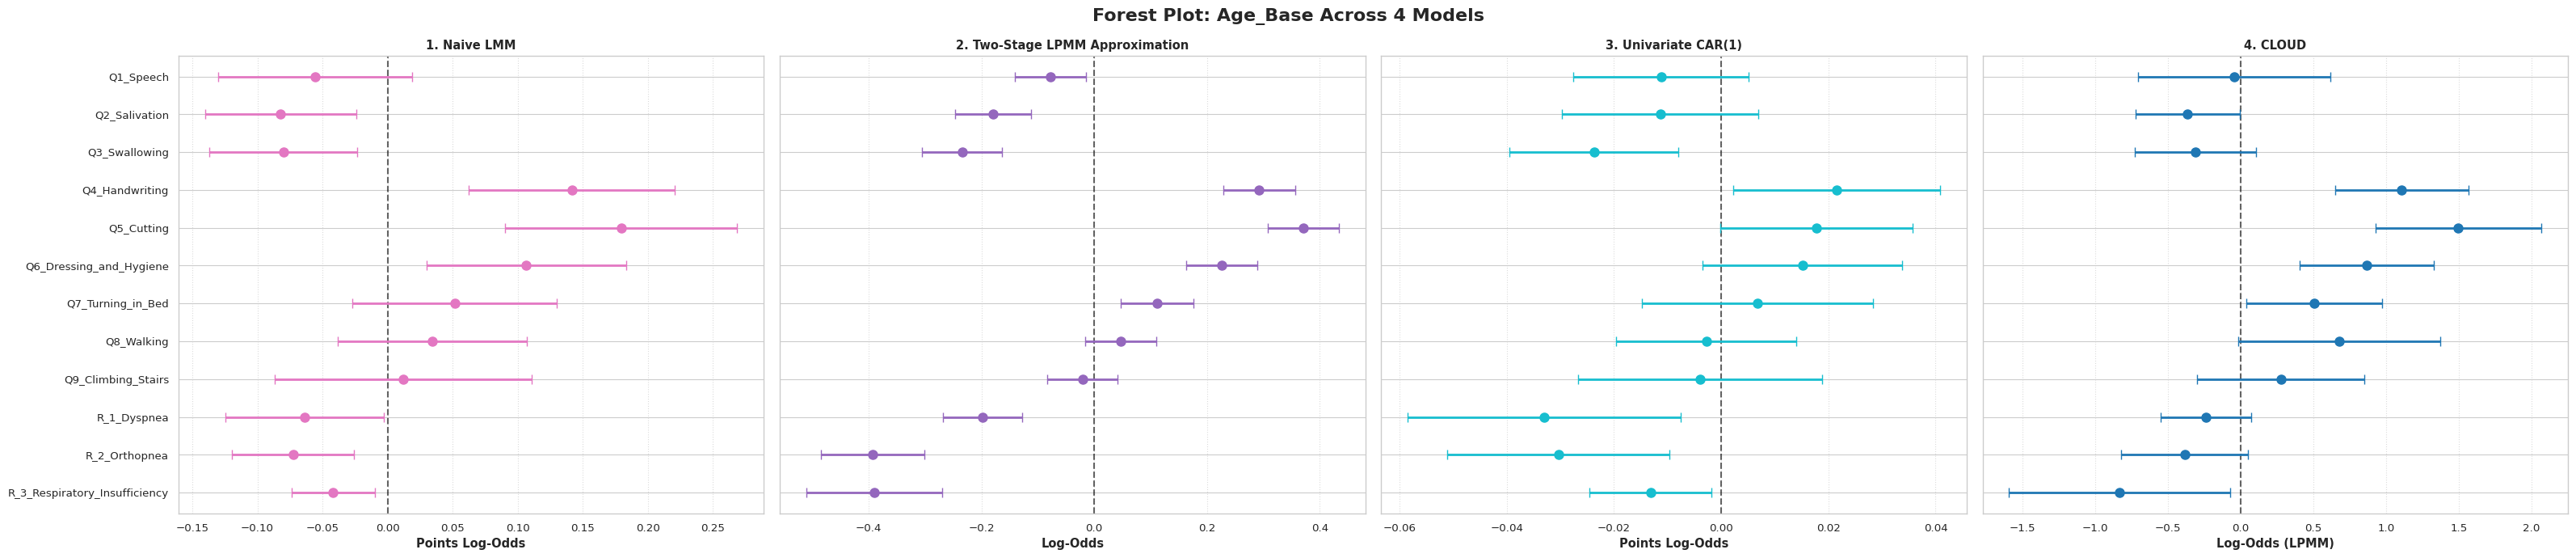

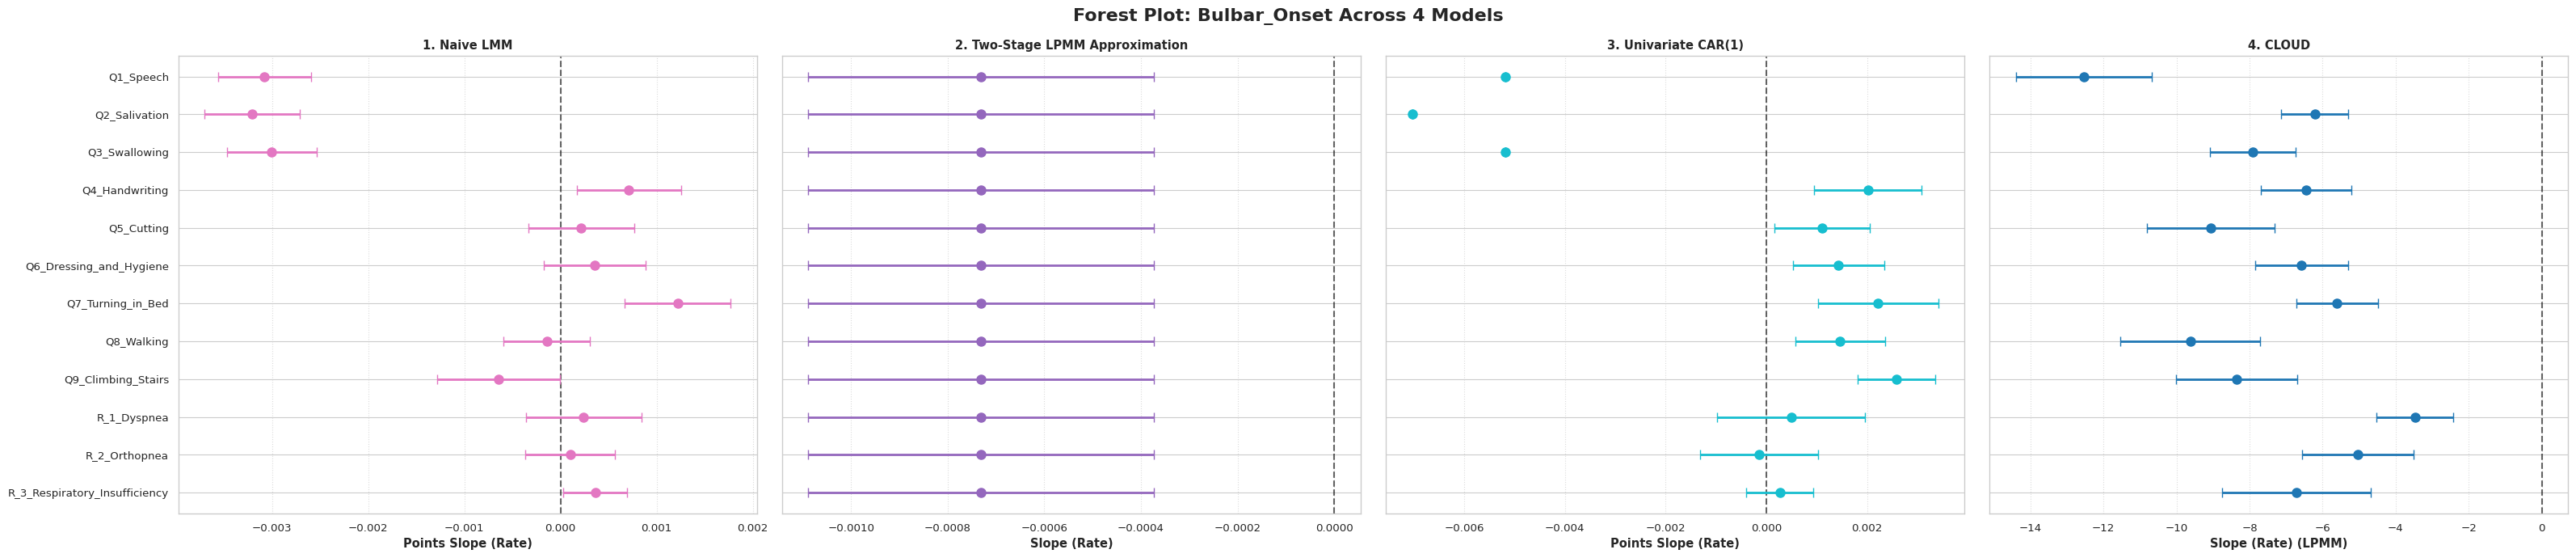

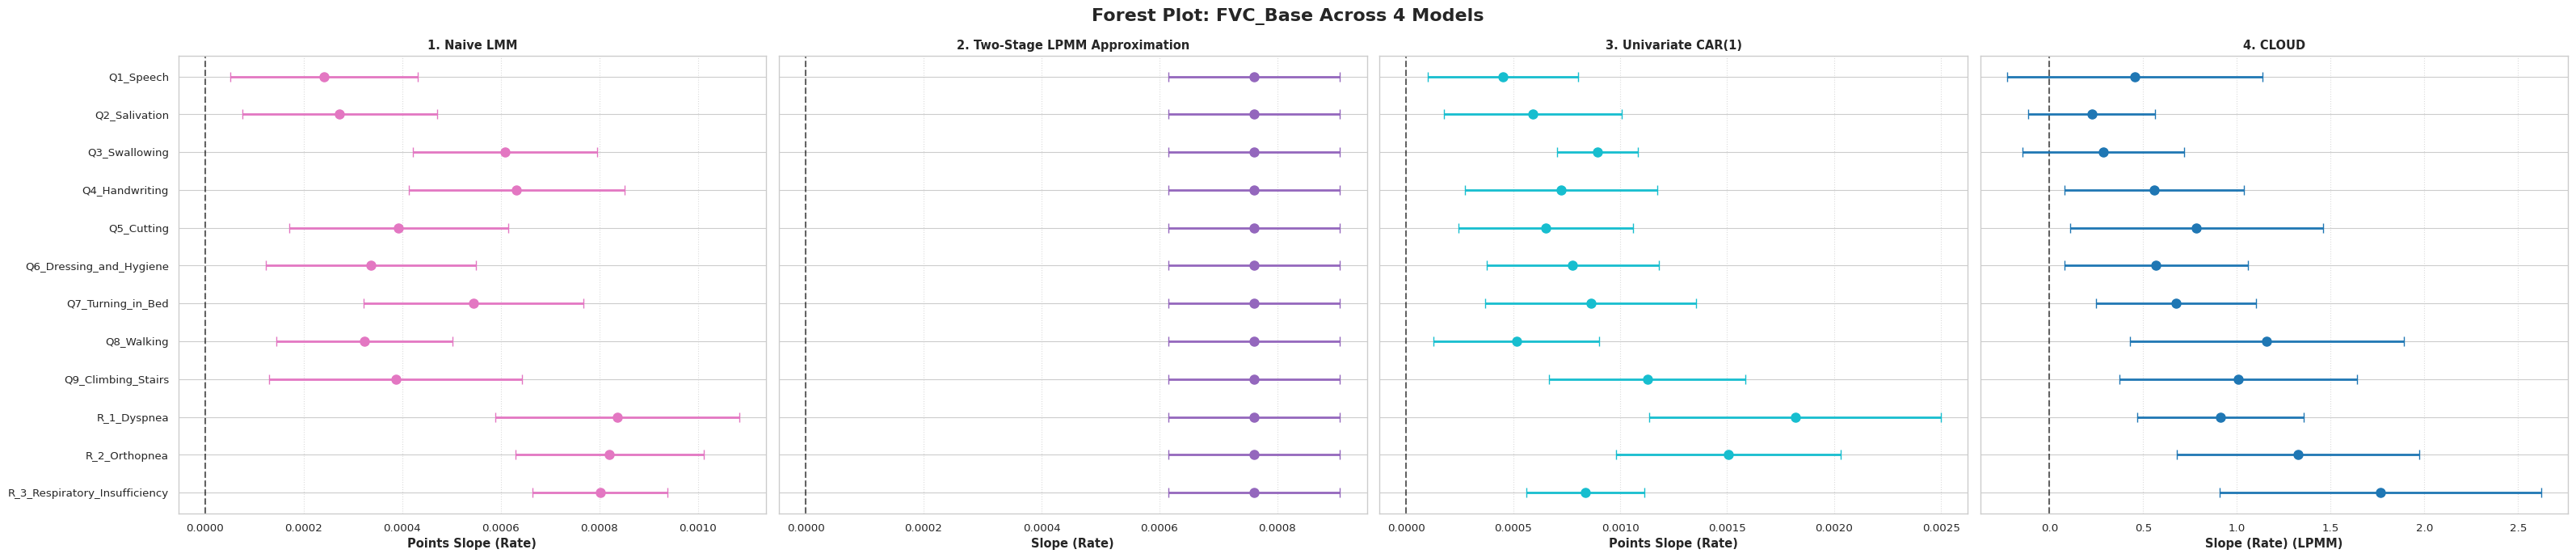

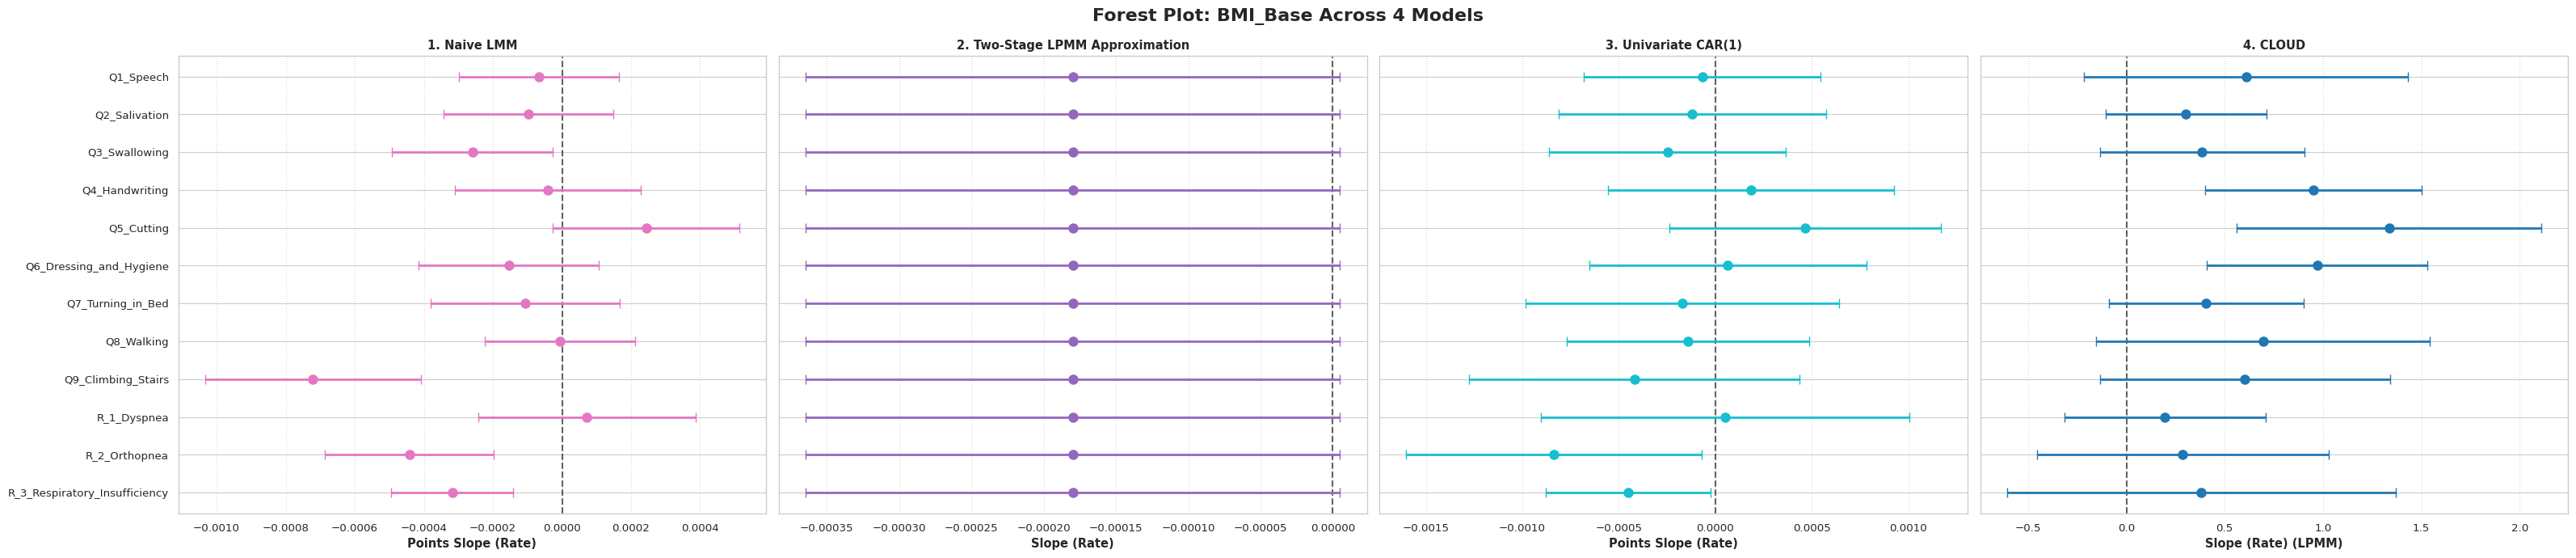

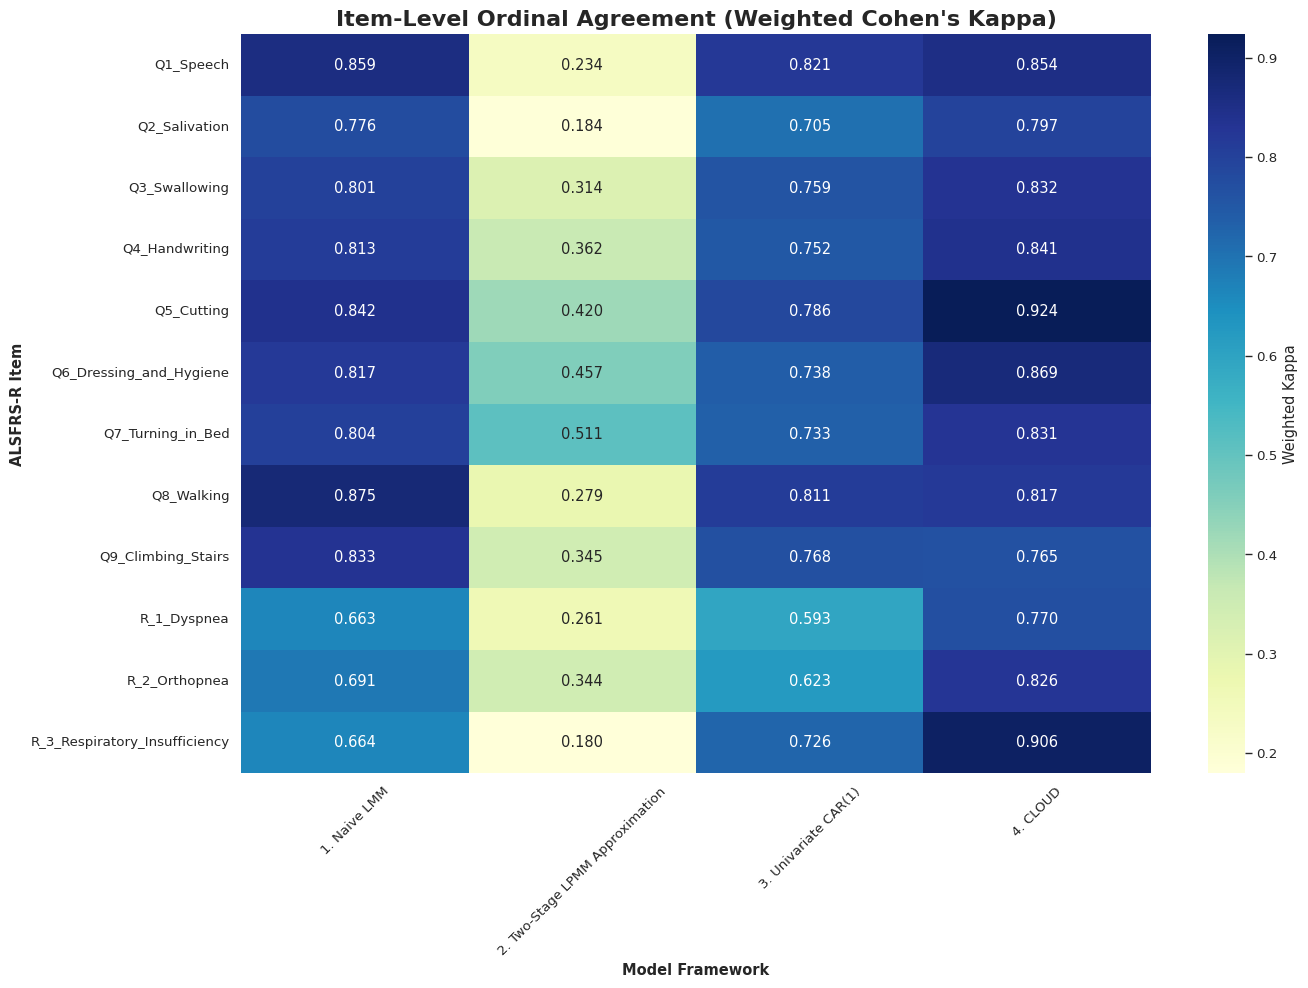

In [15]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, cohen_kappa_score
from scipy.special import expit
from girth import grm_mml
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# ==========================================
# 0. CONFIGURATION & FEATURE ENGINEERING
# ==========================================
print("=== STARTING THE BULLETPROOF 6-MODEL ABLATION PIPELINE ===")

DATA_FILE = "proact_preprocessed_S1.csv"         
MCMC_FILES = {
    '4. CLOUD': "../raw_results/results_S1_dahlou_ncp_cov_run1.csv"
}

df = pd.read_csv(DATA_FILE)

mcmc_dfs = {}
for name, path in MCMC_FILES.items():
    try:
        mcmc_dfs[name] = pd.read_csv(path)
    except Exception as e:
        print(f"[WARNING] Could not load {path}: {e}")

domains = {
    'Bulbar': ['Q1_Speech', 'Q2_Salivation', 'Q3_Swallowing'],
    'Fine_Motor': ['Q4_Handwriting', 'Q5_Cutting', 'Q6_Dressing_and_Hygiene'],
    'Gross_Motor': ['Q7_Turning_in_Bed', 'Q8_Walking', 'Q9_Climbing_Stairs'],
    'Respiratory': ['R_1_Dyspnea', 'R_2_Orthopnea', 'R_3_Respiratory_Insufficiency']
}
all_items = [item for sublist in domains.values() for item in sublist]
scenarios = {'Total Score': all_items, **domains}

meas_covariates = ['Sex_Female', 'Treatment_Active', 'Age_Base']
dyn_covariates = ['Bulbar_Onset', 'FVC_Base', 'BMI_Base']
all_covariates = meas_covariates + dyn_covariates

# Prepare aggregations and lags
df['Total Score'] = df[all_items].sum(axis=1)
for dom, items in domains.items():
    df[dom] = df[items].sum(axis=1)

df = df.sort_values(by=['subject_id', 'ALSFRS_Delta'])
df['Delta_Lag'] = df.groupby('subject_id')['ALSFRS_Delta'].shift(1)
df['Time_Gap'] = df['ALSFRS_Delta'] - df['Delta_Lag']

# FEATURE ENGINEERING: Time Interactions for Dynamic Covariates
for c in dyn_covariates:
    df[f'{c}_x_Time'] = df[c] * df['ALSFRS_Delta']
    df[f'{c}_x_Gap'] = df[c] * df['Time_Gap']

meas_str = " + ".join(meas_covariates)
dyn_time_str = " + ".join([f"{c}_x_Time" for c in dyn_covariates])
dyn_gap_str = " + ".join([f"{c}_x_Gap" for c in dyn_covariates])

df['Total_Z'] = (df['Total Score'] - df['Total Score'].mean()) / df['Total Score'].std()

metrics_results = []
covariate_results = []

# --- SAFE EXTRACTION HELPERS ---
def get_z(m, term):
    try: 
        v = m.tvalues[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_se(m, term):
    try: 
        v = m.bse[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def get_est(m, term):
    try: 
        v = m.params[term]
        return 0.0 if pd.isna(v) else v
    except: return 0.0

def add_metrics(model_name, level, target, actual, expected):
    mask = ~np.isnan(expected) & ~np.isnan(actual)
    if not np.any(mask): return
    actual_m, expected_m = actual[mask], expected[mask]
    
    rmse = np.sqrt(mean_squared_error(actual_m, expected_m))
    mae = mean_absolute_error(actual_m, expected_m)
    if level == 'Item':
        pred_cat = np.clip(np.round(expected_m), 0, 4)
        exact = np.mean(pred_cat == actual_m) * 100
        kappa = cohen_kappa_score(actual_m, pred_cat, weights='linear')
    else:
        exact, kappa = np.nan, np.nan
        
    metrics_results.append({
        'Model': model_name, 'Level': level, 'Target': target,
        'RMSE': rmse, 'MAE': mae, 'Exact_Match_%': exact, 'Weighted_Kappa': kappa
    })

def get_irt_exp(theta, disc, diffs):
    p_ge = [expit(disc * (theta - th)) for th in diffs]
    p4, p3, p2, p1, p0 = p_ge[3], p_ge[2]-p_ge[3], p_ge[1]-p_ge[2], p_ge[0]-p_ge[1], 1.0-p_ge[0]
    return (0*p0) + (1*p1) + (2*p2) + (3*p3) + (4*p4)

# ==========================================
# 1. BASELINES 1-3: FIT & PREDICT
# ==========================================
print("\nFitting Baseline Models with Robust Error Catching...")

# Model 2 Stage 1: Extract Two-Stage LPMM Trajectory 
lpmm_dyn = smf.mixedlm(f"Total_Z ~ ALSFRS_Delta + {dyn_time_str}", data=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates]), groups=df.dropna(subset=['Total_Z'] + [f"{c}_x_Time" for c in dyn_covariates])["subject_id"]).fit(reml=False, disp=False)
df['Lambda_it'] = lpmm_dyn.fittedvalues
lpmm_dyn_z = {c: get_z(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_se = {c: get_se(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}
lpmm_dyn_est = {c: get_est(lpmm_dyn, f'{c}_x_Time') for c in dyn_covariates}

for item in all_items:
    df['Item_Lag'] = df.groupby('subject_id')[item].shift(1) 
    req_cols = [item, 'Lambda_it', 'Item_Lag', 'Time_Gap', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]
    df_clean = df.dropna(subset=req_cols).copy()
    df_clean['Item_Cat'] = pd.Categorical(df_clean[item].astype(int), ordered=True)
    
    # --- Model 1: Naive LMM ---
    m1 = None
    try: 
        m1 = smf.mixedlm(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception as e: 
        try: m1 = smf.ols(f"{item} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}", data=df_clean).fit()
        except Exception: pass

    if m1 is not None:
        add_metrics('1. Naive LMM', 'Item', item, df_clean[item].values, np.clip(m1.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, c), 'SE': get_se(m1, c), 'Est': get_est(m1, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '1. Naive LMM', 'Z_Score': get_z(m1, f'{c}_x_Time'), 'SE': get_se(m1, f'{c}_x_Time'), 'Est': get_est(m1, f'{c}_x_Time')})


    # --- Model 3: Univariate CAR(1) ---
    m3 = None
    try: 
        m3 = smf.mixedlm(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean, groups=df_clean["subject_id"]).fit(reml=False, disp=False)
    except Exception: 
        try: m3 = smf.ols(f"{item} ~ Item_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_clean).fit()
        except Exception: pass
            
    if m3 is not None:
        add_metrics('3. Univariate CAR(1)', 'Item', item, df_clean[item].values, np.clip(m3.fittedvalues.values, 0, 4))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, c), 'SE': get_se(m3, c), 'Est': get_est(m3, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '3. Univariate CAR(1)', 'Z_Score': get_z(m3, f'{c}_x_Gap'), 'SE': get_se(m3, f'{c}_x_Gap'), 'Est': get_est(m3, f'{c}_x_Gap')})

    # --- Model 2: Two-Stage LPMM Approximation ---
    try:
        exog_m2 = ['Lambda_it'] + meas_covariates
        m2 = OrderedModel(df_clean['Item_Cat'], df_clean[exog_m2], distr='logit').fit(method='bfgs', disp=False)
        add_metrics('2. Two-Stage LPMM Approximation', 'Item', item, df_clean[item].values, (m2.predict(df_clean[exog_m2]).values * np.arange(5)).sum(axis=1))
        for c in meas_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. Two-Stage LPMM Approximation', 'Z_Score': get_z(m2, c), 'SE': get_se(m2, c), 'Est': get_est(m2, c)})
        for c in dyn_covariates: covariate_results.append({'Item': item, 'Covariate': c, 'Model': '2. Two-Stage LPMM Approximation', 'Z_Score': lpmm_dyn_z[c], 'SE': lpmm_dyn_se[c], 'Est': lpmm_dyn_est[c]})
    except Exception: pass


for target, items in scenarios.items():
    level = 'Overall' if target == 'Total Score' else 'Domain'
    max_val = 48 if level == 'Overall' else 12
    df_agg = df.dropna(subset=[target, 'Factor_Lag', 'Time_Gap', 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates] + [f"{c}_x_Gap" for c in dyn_covariates]).copy() if 'Factor_Lag' in df.columns else df.dropna(subset=[target, 'Lambda_it', 'ALSFRS_Delta'] + meas_covariates + [f"{c}_x_Time" for c in dyn_covariates]).copy()
    
    agg_form_1 = f"Q('{target}') ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}" if ' ' in target else f"{target} ~ ALSFRS_Delta + {meas_str} + {dyn_time_str}"
    
    # --- Model 1: Naive LMM (Macro) ---
    agg1 = None
    try: agg1 = smf.mixedlm(agg_form_1, data=df_agg, groups=df_agg["subject_id"]).fit(reml=False, disp=False)
    except Exception:
        try: agg1 = smf.ols(agg_form_1, data=df_agg).fit()
        except Exception: pass
    if agg1 is not None:
        add_metrics('1. Naive LMM', level, target, df_agg[target].values, np.clip(agg1.fittedvalues.values, 0, max_val))

    # --- Model 3: Univariate CAR(1) (Macro) ---
    try:
        fa = FactorAnalysis(n_components=1).fit(df_agg[items])
        df_agg['Factor'] = fa.transform(df_agg[items])[:, 0]
        df_agg['Factor_Lag'] = df_agg.groupby('subject_id')['Factor'].shift(1)
        df_fa = df_agg.dropna(subset=['Factor_Lag', 'Time_Gap']).copy()
        
        if len(df_fa) > 0:
            m3_agg = smf.mixedlm(f"Factor ~ Factor_Lag * Time_Gap + {meas_str} + {dyn_gap_str}", data=df_fa, groups=df_fa["subject_id"]).fit(reml=False, disp=False)
            exp_fa = np.zeros(len(df_fa))
            for i, item in enumerate(items): 
                exp_fa += np.clip((m3_agg.fittedvalues.values * fa.components_[0, i]) + df_fa[items].mean().values[i], 0, 4)
            add_metrics('3. Univariate CAR(1)', level, target, df_fa[target].values, exp_fa)
    except Exception: pass

    # --- Model 2: Two-Stage LPMM Approximation (Macro) ---
    exp_lpmm = np.zeros(len(df_agg))
    for item in items:
        df_agg['Item_Cat'] = pd.Categorical(df_agg[item].astype(int), ordered=True)
        try:
            m2_i = OrderedModel(df_agg['Item_Cat'], df_agg[['Lambda_it'] + meas_covariates], distr='logit').fit(method='bfgs', disp=False)
            exp_lpmm += (m2_i.predict(df_agg[['Lambda_it'] + meas_covariates]).values * np.arange(5)).sum(axis=1)
        except Exception: pass
    if np.any(exp_lpmm):
        add_metrics('2. Two-Stage LPMM Approximation', level, target, df_agg[target].values, exp_lpmm)

# ==========================================
# 2. EXTRACT CLOUD (MCMC) METRICS & COVS
# ==========================================
print("\nExtracting CLOUD (MCMC) Parameters across restricted domains...")

def ext_stan(df_m, param, shape):
    out = np.zeros(shape)
    pattern = rf"^{param}\["
    subset = df_m[df_m['Parameter'].str.contains(pattern, regex=True)]
    for _, r in subset.iterrows():
        try:
            idx_str = re.search(r'\[(.*?)\]', r['Parameter'])
            if not idx_str: continue
            idx = [int(i)-1 for i in idx_str.group(1).split(',')]
            
            valid = True
            for j, dim_idx in enumerate(idx):
                if dim_idx >= shape[j] or dim_idx < 0: valid = False
            if not valid: continue
            
            if len(idx)==1: out[idx[0]] = r['Estimate']
            elif len(idx)==2: out[idx[0], idx[1]] = r['Estimate']
            elif len(idx)==3: out[idx[0], idx[1], idx[2]] = r['Estimate']
        except Exception:
            pass
    return out

X_m = df[['Sex_Female', 'Treatment_Active', 'Age_Base']].fillna(0).values
actual_sc = df[all_items].values
sub_map = {sub: i for i, sub in enumerate(df['subject_id'].unique())}
ID = df['subject_id'].map(sub_map).values
domain_idx_full = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8], 3: [9,10,11]}

for model_name, df_mcmc in mcmc_dfs.items():
    print(f" -> Processing {model_name}...")
    is_3d = '3D' in model_name
    valid_k = 9 if is_3d else 12
    domain_idx = {0: [0,1,2], 1: [3,4,5], 2: [6,7,8]} if is_3d else domain_idx_full
    
    theta = ext_stan(df_mcmc, 'theta', (12, 4))
    lam   = ext_stan(df_mcmc, 'lambda', (12,))
    beta  = ext_stan(df_mcmc, 'beta', (12, 3))
    xi    = ext_stan(df_mcmc, 'xi', (4, len(df)))
    b     = ext_stan(df_mcmc, 'b', (len(sub_map), 12))
    
    exp_sc = np.full((len(df), 12), np.nan)
    
    for i in range(len(df)):
        for d, items in domain_idx.items():
            for k in items:
                eta = np.dot(X_m[i,:], beta[k]) + lam[k]*xi[d,i] + b[ID[i],k]
                p = [expit(1.0 * (eta - th)) for th in theta[k]]
                p4, p3, p2, p1, p0 = p[3], p[2]-p[3], p[1]-p[2], p[0]-p[1], 1.0-p[0]
                exp_sc[i,k] = (0*p0)+(1*p1)+(2*p2)+(3*p3)+(4*p4)

    for k in range(valid_k): 
        add_metrics(model_name, 'Item', all_items[k], actual_sc[:,k], exp_sc[:,k])
    for d, items in domain_idx.items(): 
        add_metrics(model_name, 'Domain', list(domains.keys())[d], actual_sc[:,items].sum(axis=1), exp_sc[:,items].sum(axis=1))
    
    if not is_3d:
        add_metrics(model_name, 'Overall', 'Total Score', actual_sc.sum(axis=1), exp_sc.sum(axis=1))
        
    cov_map_beta = {1: 'Sex_Female', 2: 'Treatment_Active', 3: 'Age_Base'}
    cov_map_alpha = {1: 'Bulbar_Onset', 2: 'FVC_Base', 3: 'BMI_Base'}

    df_beta = df_mcmc[df_mcmc['Parameter'].str.contains(r'^beta\[', regex=True)].copy()
    if not df_beta.empty:
        df_beta[['Dim1', 'Cov_idx']] = df_beta['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_beta.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_beta: continue
            k_idx = int(row['Dim1']) - 1
            if k_idx >= valid_k: continue
            
            c_name = cov_map_beta[c_idx]
            item_name = all_items[k_idx]
            est = row['Estimate']
            se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': est/se if se!=0 else 0.0, 'SE': se, 'Est': est})

    df_alpha = df_mcmc[df_mcmc['Parameter'].str.contains(r'^alpha_dyn\[', regex=True)].copy()
    if not df_alpha.empty:
        df_alpha[['Dim1', 'Cov_idx']] = df_alpha['Parameter'].str.extract(r'\[(\d+),(\d+)\]').astype(int)
        for _, row in df_alpha.iterrows():
            c_idx = int(row['Cov_idx'])
            if c_idx not in cov_map_alpha: continue
            dom_idx = int(row['Dim1']) - 1
            if dom_idx not in domain_idx: continue
            
            c_name = cov_map_alpha[c_idx]
            phi_est = row['Estimate']
            phi_se = (row['97.5%'] - row['2.5%']) / (2 * 1.96)
            
            for k_idx in domain_idx[dom_idx]:
                item_name = all_items[k_idx]
                lam_k = lam[k_idx]
                comp_est = lam_k * phi_est if c_name in dyn_covariates else -1 * lam_k * phi_est
                comp_se = abs(lam_k) * phi_se
                covariate_results.append({'Item': item_name, 'Covariate': c_name, 'Model': model_name, 'Z_Score': comp_est/comp_se if comp_se!=0 else 0.0, 'SE': comp_se, 'Est': comp_est})

# ==========================================
# 3. AGGREGATION & EXPORT
# ==========================================
print("\nAggregating Results...")
df_metrics = pd.DataFrame(metrics_results).dropna(subset=['RMSE'])
df_metrics['Level'] = pd.Categorical(df_metrics['Level'], categories=['Overall', 'Domain', 'Item'], ordered=True)
df_metrics.to_csv("master_predictive_metrics.csv", index=False)

df_covs = pd.DataFrame(covariate_results)
df_covs['Item'] = pd.Categorical(df_covs['Item'], categories=reversed(all_items), ordered=True)

# Updated Order
mod_order = ['1. Naive LMM', '2. Two-Stage LPMM Approximation', '3. Univariate CAR(1)',
             '4. CLOUD']

df_covs['Model'] = pd.Categorical(df_covs['Model'], categories=mod_order, ordered=True)
df_covs['Z_Score'] = df_covs['Z_Score'].fillna(0.0)
df_covs.to_csv("master_covariates.csv", index=False)

# ==========================================
# 4. VISUALIZATION
# ==========================================
print("Generating Final Publication Visuals in PNG, SVG, and PDF formats...")

def save_multiformat(base_filename):
    plt.savefig(f"{base_filename}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{base_filename}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{base_filename}.pdf", format='pdf', bbox_inches='tight')

model_colors = {
    '1. Naive LMM': '#e377c2',          
    '2. Two-Stage LPMM Approximation': '#9467bd',      
    '3. Univariate CAR(1)': '#17becf',     
    '4. CLOUD': '#1f77b4'
}

# --- DATA PREP FOR MACRO PLOTS ---
df_macro = df_metrics[df_metrics['Level'].isin(['Overall', 'Domain'])].copy()
target_order = ['Total Score', 'Bulbar', 'Fine_Motor', 'Gross_Motor', 'Respiratory']
df_macro['Target'] = pd.Categorical(df_macro['Target'], categories=target_order, ordered=True)

# Plot A: Macro-Level RMSE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='RMSE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level RMSE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Root Mean Squared Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_A_Macro_RMSE')

# Plot B: Macro-Level MAE
plt.figure(figsize=(16, 7))
sns.barplot(data=df_macro, x='Target', y='MAE', hue='Model', palette=model_colors, hue_order=mod_order)
plt.title('Macro-Level MAE (Total Score & Domains)', fontweight='bold', fontsize=16)
plt.ylabel('Mean Absolute Error', fontweight='bold')
plt.xlabel('Clinical Target', fontweight='bold')
plt.legend(title='Model Framework', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_multiformat('Fig_B_Macro_MAE')

# Plot C: Covariate Heatmap
fig, axes = plt.subplots(2, 3, figsize=(24, 14), sharey=True, sharex=True)
fig.suptitle("Standardized Covariate Effect Sizes (Z-Scores)", fontweight='bold', fontsize=18)
cmap = sns.diverging_palette(10, 240, as_cmap=True)
for i, cov in enumerate(all_covariates):
    ax = axes.flatten()[i]
    pivot = df_covs[df_covs['Covariate'] == cov].pivot(index='Item', columns='Model', values='Z_Score')
    sns.heatmap(pivot[mod_order], annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax, vmin=-5, vmax=5, cbar_kws={'label': 'Z-Score'})
    ax.set_title(cov, fontweight='bold')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
save_multiformat("Fig_C_Covariate_Heatmap")

# Plot D: Forest Plots
for cov in all_covariates:
    subset = df_covs[df_covs['Covariate'] == cov]
    fig, axes = plt.subplots(1, len(mod_order), figsize=(32, 7), sharey=True)
    fig.suptitle(f"Forest Plot: {cov} Across {len(mod_order)} Models", fontweight='bold', fontsize=16)
    base_unit = "Log-Odds" if cov in meas_covariates else "Slope (Rate)"
    x_labels = [f"Points {base_unit}", f"{base_unit}", f"Points {base_unit}", f"{base_unit} (LPMM)", 
                f"{base_unit} (Full)", f"{base_unit} (Diag)"]
    
    for i, model in enumerate(mod_order):
        ax = axes[i]
        mod_data = subset[subset['Model'] == model].sort_values('Item')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
        if not mod_data.empty:
            c_val = model_colors[model]
            ax.errorbar(mod_data['Est'], mod_data['Item'], xerr=mod_data['SE'] * 1.96, fmt='o', color=c_val, ecolor=c_val, elinewidth=2, capsize=4, markersize=8)
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel(x_labels[i], fontweight='bold')
        ax.grid(True, axis='x', linestyle=':', alpha=0.7)
    plt.tight_layout()
    save_multiformat(f"Fig_D_Forest_{cov}")

# Plot E: Item-Level Ordinal Agreement (Kappa Heatmap)
plt.figure(figsize=(14, 10))
df_item = df_metrics[df_metrics['Level'] == 'Item']
kappa_pivot = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')[mod_order]
sns.heatmap(kappa_pivot, annot=True, cmap='YlGnBu', fmt=".3f", cbar_kws={'label': 'Weighted Kappa'})
plt.title('Item-Level Ordinal Agreement (Weighted Cohen\'s Kappa)', fontweight='bold', fontsize=16)
plt.ylabel('ALSFRS-R Item', fontweight='bold')
plt.xlabel('Model Framework', fontweight='bold')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_multiformat('Fig_E_Item_Kappa_Heatmap')

# ==========================================
# 5. TERMINAL OUTPUT
# ==========================================
print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN RMSE)")
print("="*105)
piv_macro_rmse = df_macro.pivot(index='Target', columns='Model', values='RMSE')
print(piv_macro_rmse[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: MACRO-LEVEL ACCURACY (TOTAL SCORE & DOMAIN MAE)")
print("="*105)
piv_macro_mae = df_macro.pivot(index='Target', columns='Model', values='MAE')
print(piv_macro_mae[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n" + "="*105)
print("TERMINAL EXPORT: ITEM-LEVEL ORDINAL AGREEMENT (EXACT MATCH % / KAPPA)")
print("="*105)
piv_item_exact = df_item.pivot(index='Target', columns='Model', values='Exact_Match_%')
piv_item_kappa = df_item.pivot(index='Target', columns='Model', values='Weighted_Kappa')
print("--- ITEM EXACT MATCH % ---")
print(piv_item_exact[mod_order].to_string(float_format="{:.1f}".format, na_rep="-"))
print("\n--- ITEM WEIGHTED KAPPA ---")
print(piv_item_kappa[mod_order].to_string(float_format="{:.3f}".format, na_rep="-"))

print("\n=== PIPELINE 100% COMPLETE ===")